<a href="https://colab.research.google.com/github/hengy-w4/261Kaggle/blob/main/Kaggle_competition_JAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ImageNet Backbone

Finding: imagenet trained doesnt work!

# setup stuff

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/MyDrive')

In [ ]:


# download images from kaggle
# comment out if need to use
'''
DATASET_PATH = "./chest_xray"
os.makedirs(DATASET_PATH, exist_ok=True)

import kagglehub
import os
import shutil

# Download latest version
KAGGLE_TOKEN = '' # paste token here
os.environ['KAGGLE_API_TOKEN'] = KAGGLE_TOKEN

print("Downloading competition files...")
download_path = kagglehub.competition_download('bst-261-2026-pneumonia-chest-x-ray-classification')
print(f"Files downloaded to Kaggle cache: {download_path}")
print(f"Copying files from {download_path} to {DATASET_PATH}...")
if os.path.exists(DATASET_PATH) and os.path.isdir(DATASET_PATH):
    shutil.rmtree(DATASET_PATH)
os.makedirs(DATASET_PATH, exist_ok=True)
for item in os.listdir(download_path):
    s = os.path.join(download_path, item)
    d = os.path.join(DATASET_PATH, item)
    if os.path.isdir(s):
        shutil.copytree(s, d, symlinks=False, ignore=None)
    else:
        shutil.copy2(s, d)

print(f"Competition files are now available in: {DATASET_PATH}")

# Clear the environment variable after use for security, if desired
del os.environ['KAGGLE_API_TOKEN']
'''

'\nDATASET_PATH = "./chest_xray"\nos.makedirs(DATASET_PATH, exist_ok=True)\n\nimport kagglehub\nimport os\nimport shutil\n\n# Download latest version\nKAGGLE_TOKEN = \'\' # paste token here\nos.environ[\'KAGGLE_API_TOKEN\'] = KAGGLE_TOKEN\n\nprint("Downloading competition files...")\ndownload_path = kagglehub.competition_download(\'bst-261-2026-pneumonia-chest-x-ray-classification\')\nprint(f"Files downloaded to Kaggle cache: {download_path}")\nprint(f"Copying files from {download_path} to {DATASET_PATH}...")\nif os.path.exists(DATASET_PATH) and os.path.isdir(DATASET_PATH):\n    shutil.rmtree(DATASET_PATH)\nos.makedirs(DATASET_PATH, exist_ok=True)\nfor item in os.listdir(download_path):\n    s = os.path.join(download_path, item)\n    d = os.path.join(DATASET_PATH, item)\n    if os.path.isdir(s):\n        shutil.copytree(s, d, symlinks=False, ignore=None)\n    else:\n        shutil.copy2(s, d)\n\nprint(f"Competition files are now available in: {DATASET_PATH}")\n\n# Clear the environment

In [ ]:

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
DATASET_PATH = "./chest_xray"

# Downloaded Dataset Path (in google drive)
IMG_CLASSES = ['NORMAL', 'PNEUMONIA']

def load_sample_imgs(path):
    imgs = []
    for cls in IMG_CLASSES:
        dir_path = os.path.join(path, cls)
        img_name = os.listdir(dir_path)[0]
        img = cv2.imread(os.path.join(dir_path, img_name))
        cls_index = IMG_CLASSES.index(cls)
        imgs.append([img, cls_index])

    return imgs

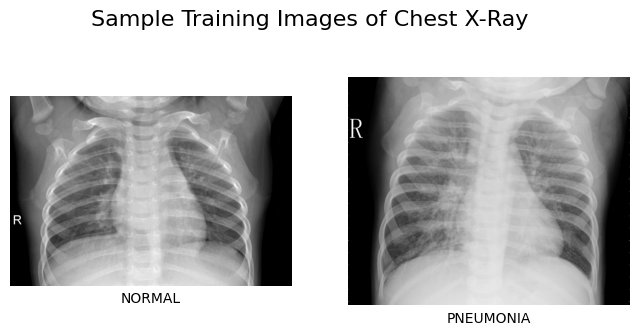

In [ ]:
sample_imgs = load_sample_imgs(os.path.join(DATASET_PATH, 'train'))
fig, ax = plt.subplots(ncols=2, figsize=(8, 4))

plt.suptitle('Sample Training Images of Chest X-Ray', fontsize=16, y=0.95)

for index in range(2):
    img, cls_index = sample_imgs[index]
    ax[index].imshow(img)
    ax[index].set_xticks([])
    ax[index].set_yticks([])
    ax[index].set_xlabel(IMG_CLASSES[cls_index])
    ax[index].spines['top'].set_visible(False)
    ax[index].spines['right'].set_visible(False)
    ax[index].spines['left'].set_visible(False)
    ax[index].spines['bottom'].set_visible(False)

plt.show()

In [ ]:
#IMG_SIZE represents height and width of an image
#TODO: Choose an appropriate Image Size, example: IMG_SIZE = 32, IMG_SIZE = 64, etc.
DATASET_PATH = "./chest_xray"
IMG_SIZE = 64

def load_data(path):
    data = []
    for cls_index, cls in enumerate(IMG_CLASSES):
        dir_path = os.path.join(path, cls)
        for img_name in os.listdir(dir_path):
            img_path = os.path.join(dir_path, img_name)
            img = cv2.imread(img_path)

            if img is not None:
                h, w = img.shape[:2]

                # Calculate padding to make the image square
                if h != w:
                    # Find the difference and split it between sides
                    diff = abs(w - h)
                    pad1 = diff // 2
                    pad2 = diff - pad1

                    if w > h: # Wide image (like your 32x64)
                        img = cv2.copyMakeBorder(img, pad1, pad2, 0, 0,
                                                cv2.BORDER_CONSTANT, value=[0, 0, 0])
                    else: # Tall image
                        img = cv2.copyMakeBorder(img, 0, 0, pad1, pad2,
                                                cv2.BORDER_CONSTANT, value=[0, 0, 0])

                # Now that it's a square, resize it
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                data.append([img, cls_index])
    return data

Now after developing the data loading function, we will read the `Training` and `Validation` datasets. For now we will not going to load the `Testing` dataset because it will be used in the end to test the CNN models.

In [ ]:
train_data = load_data(os.path.join(DATASET_PATH, 'train'))
valid_data = load_data(os.path.join(DATASET_PATH, 'val'))

# print number of images in each dataset
print(f'There are {len(train_data)} Training Images.')
print(f'There are {len(valid_data)} Validation Images.')

KeyboardInterrupt: 

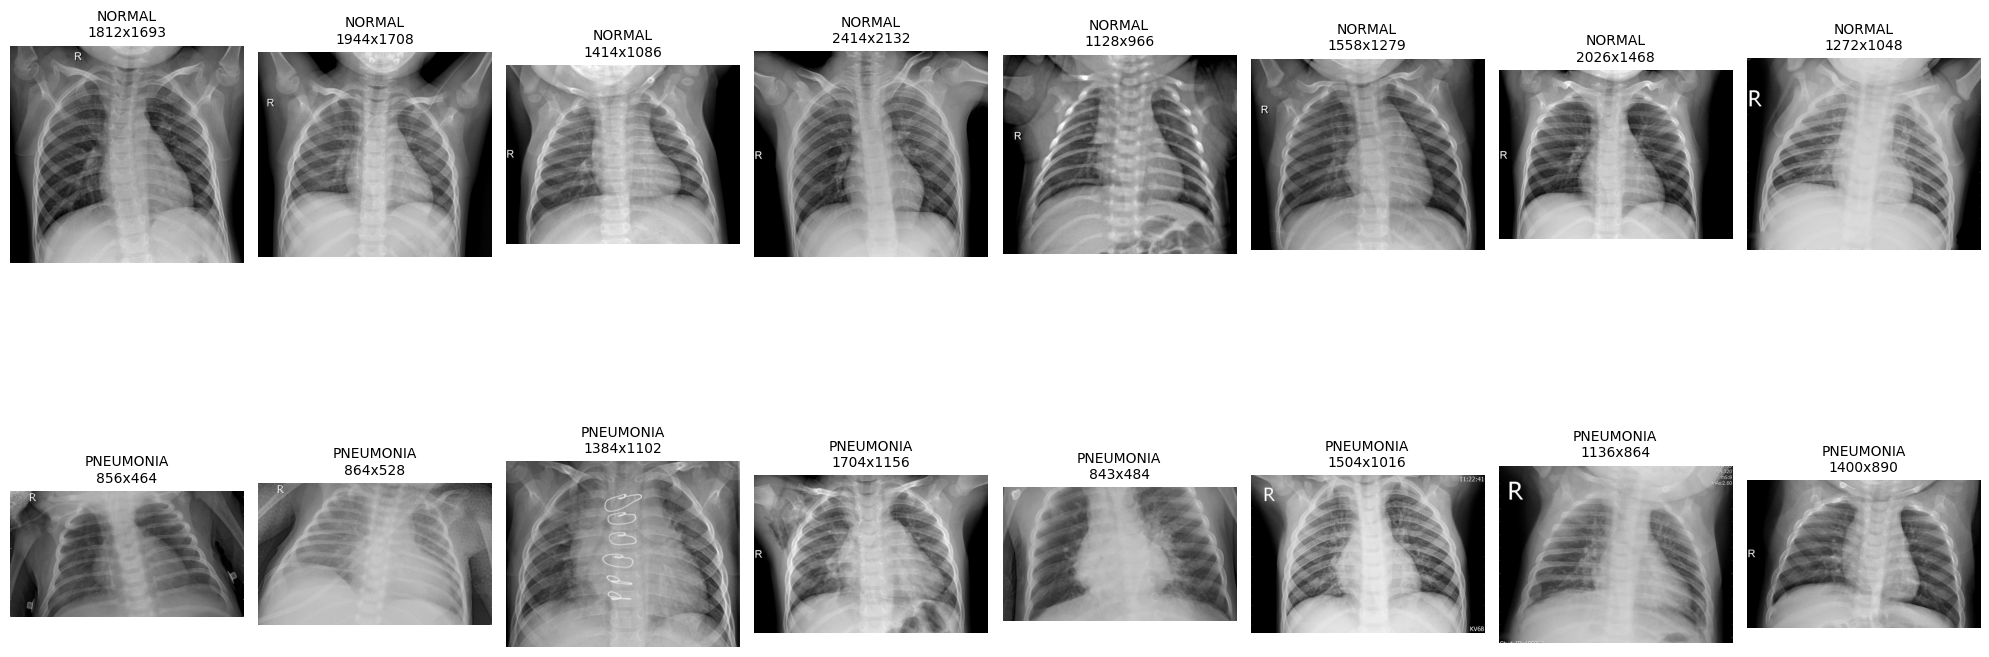

In [ ]:
import matplotlib.pyplot as plt
import os
import cv2
import random

def visualize_samples(base_path, n_samples=8):
    fig, axes = plt.subplots(len(IMG_CLASSES), n_samples, figsize=(20, 10))

    for i, cls in enumerate(IMG_CLASSES):
        dir_path = os.path.join(base_path, cls)
        # Get all image names in the directory
        all_imgs = [f for f in os.listdir(dir_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        # Randomly sample images
        sampled_imgs = random.sample(all_imgs, n_samples)

        for j, img_name in enumerate(sampled_imgs):
            img_path = os.path.join(dir_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            ax = axes[i, j]
            ax.imshow(img)
            ax.set_title(f"{cls}\n{img.shape[1]}x{img.shape[0]}", fontsize=10)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Visualizing 8 samples from each class in the training folder
train_path = os.path.join(DATASET_PATH, 'train')
visualize_samples(train_path, n_samples=8)

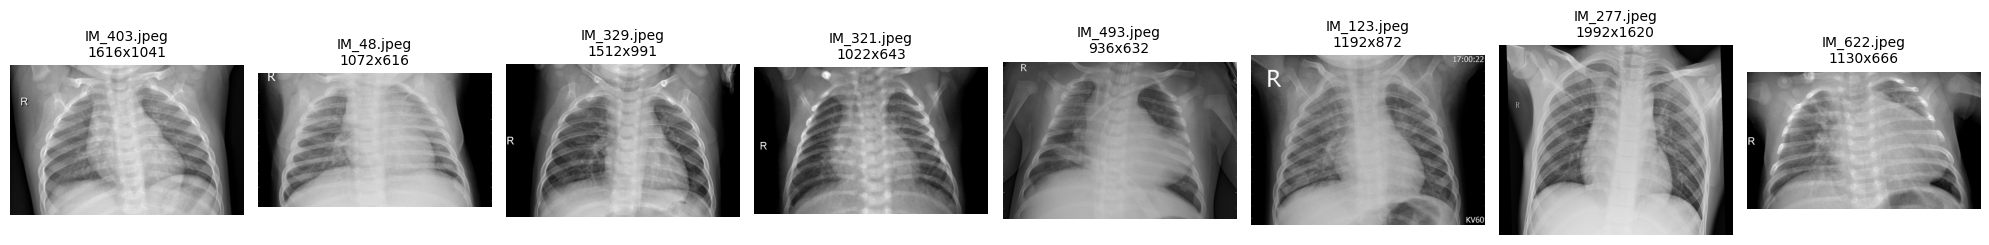

In [ ]:
import matplotlib.pyplot as plt
import os
import cv2
import random

def visualize_test_samples(base_path, n_samples=8):
    # Get all image names in the directory
    all_imgs = [f for f in os.listdir(base_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    # Randomly sample images
    sampled_imgs = random.sample(all_imgs, min(n_samples, len(all_imgs)))

    fig, axes = plt.subplots(1, len(sampled_imgs), figsize=(20, 5))
    if len(sampled_imgs) == 1:
        axes = [axes]

    for j, img_name in enumerate(sampled_imgs):
        img_path = os.path.join(base_path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            ax = axes[j]
            ax.imshow(img)
            ax.set_title(f"{img_name}\n{img.shape[1]}x{img.shape[0]}", fontsize=10)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Visualizing 8 samples from the test folder
test_path = os.path.join(DATASET_PATH, 'test')
visualize_test_samples(test_path, n_samples=8)


We can see that we don't have a good amount of data for validation set, so now we need to combine both datasets, then split into training and testing sets.


### IMPLEMENTATION
**In the cell below, first combine both sets, then split into training and validation sets. (80% for Training, 20% for Validation)**

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Combine the training and validation sets
all_data = train_data + valid_data

# Separate features (X) and labels (y) from the combined data list
X = np.array([item[0] for item in all_data])
y = np.array([item[1] for item in all_data])

# Get the indices for splitting the dataset
indices = np.arange(len(X))
train_indices, valid_indices, _, _ = train_test_split(
    indices,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Use the obtained indices to create the actual training and validation sets
x_train = X[train_indices]
x_valid = X[valid_indices]
y_train = y[train_indices]
y_valid = y[valid_indices]

# redundant but creating a tuple for compatibility with below cell
train_data = [[x_train[i], y_train[i]] for i in range(len(x_train))]
valid_data = [[x_valid[i], y_valid[i]] for i in range(len(x_valid))]

# print number of images in each dataset
print(f'There are {len(train_data)} Training Images.')
print(f'There are {len(valid_data)} Validation Images.')

---
## Section 2: Data Pre-processing

Before starting to train the Deep Learning model we need to setup the dataset for best possible results. In our case as we are working with images the first thing to note is the size of all the images in the dataset and then we can move forward with all other techniques.

In our case as we have already setup the constant value for the size of all the images in the dataset so we don't need to worry about the size of the images in the dataset. Now we have multiple other steps that we need to take, first we will going to split the features and labels from the dataset that we have prepared early.

### Implementation
In the function below provide the code to split the features and labels into their seperate lists and then return the numpy arrays for each one of them.

In [ ]:
def split_features_labels(data):
    # TODO: Split features and Labels and return numpy array for feature and labels
    features = np.array([row[0] for row in data])
    labels = np.array([row[1] for row in data])
    return features, labels

Now as the function is ready to be used, so we will going to use the function to split features and labels from the dataset. First we will going to call the function for training dataset and then for validation dataset.

In [ ]:
x_train, y_train = split_features_labels(train_data)
x_valid, y_valid = split_features_labels(valid_data)

When using TensorFlow as backend, Keras CNNs require a 4D array (which we'll also refer to as a 4D tensor) as input, with shape

$$
(\text{number_of_samples}, \text{image_height}, \text{image_width}, \text{channels}),
$$

where `number_of_samples` corresponds to the total number of images (or samples), and `image_height`, `image_width`, and `channels` correspond to the each image height, width, and channels.

By the running the cell below, we can check the tensor size of our training and validation data. First we will going to check the size of features and then we will move with labels/classes.

In [ ]:
print(f'Training Features Tensor Shape: {x_train.shape}')
print(f'Validation Features Tensor Shape: {x_valid.shape}')
print('\n')
print(f'Training Labels Tensor Shape: {y_train.shape}')
print(f'Validation Labels Tensor Shape: {y_valid.shape}')

### IMPLEMENTATION
For training and validation labels, we can see that we have tensors of shape `(200,)` and `(16,)`, which means we have a 1-D tensor. This is a binary dataset, which means we just have 2 classes in the dataset. For the better performance of the model we can use `One-Hot-Encoding` technique to One Hot Encode the labels, this is not a necessary step while working with Binary Classification data, but this is a cruicial step for Multi-Class Classification and that is why we also need to learn this step.

In the cell below you can implement the functionality to One-Hot Encode the labels of the dataset.

In [ ]:
from keras.utils import to_categorical

#TODO: Implement One HOT ENCODING for training and validation labels
y_train = to_categorical(y_train, num_classes=2)
y_valid = to_categorical(y_valid, num_classes=2)

Now after implementing the `One-Hot Encoding` functionality we can again check the shape of the labels.

In [ ]:
print(f'Training Labels Tensor Shape: {y_train.shape}')
print(f'Validation Labels Tensor Shape: {y_valid.shape}')

Now we have setup the features and labels of the dataset, let's explore the data a bit more and let us visualize the channels of the images. We know that the data is in `3 Channels` which means that the images in the dataset are having `Reg, Blue and Green` color channel which is also known as `RGB`. By running the cell below, we can visualize the image in each color channel.

In [ ]:
image = x_train[0]

# plotting the original image and the RGB channels
f, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, sharey=True)
f.set_figwidth(15)
ax1.imshow(image)

# RGB channels
# CHANNELID : 0 for Red, 1 for Green, 2 for Blue.
ax2.imshow(image[:, : , 0]) #Red
ax3.imshow(image[:, : , 1]) #Green
ax4.imshow(image[:, : , 2]) #Blue
f.suptitle('Different Channels of Chest X-Ray Image')

---
## Section 3: Data Augumentation

Data augmentation is a technique used in machine learning to artificially increase the size and diversity of a dataset by generating new data from existing data. Data augmentation provides improvement in the performance of machine learning models by exposing them to a wider range of variations in the data. Data augmentation is commonly used in computer vision applications such as image classification, object detection, and segmentation.

For data augumentation we can make use of multiple techniques like Flipping, Rotation, Scaling, Cropping, Translation, Adding Noise to the image, etc.

### IMPLEMENTATION
For Data Augumentation we will be using `ImageDataGenerator` function provided by `keras` library. In the cell below you have boilerplate code for the initialization of ImageDataGenerator object, while initializing the object, we need to pass in arguments which Augumentation techniques we need to use.

**In the code below, we already have two arguments (Augumentation Techniques), you need to provide at least 2 more arguments to Augument the data, you can provide more as you want.**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# TODO: Provide at least 2 more data augumentation parameters,
#datagen = ImageDataGenerator(rotation_range=40, width_shift_range=0.2)

# data augmentations - rotations, scaling, translation, brightness, contrast
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.1,
    shear_range=0.05,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

Now after initializing the data augumentation object, we need to use this object to visualize the dataset.

In the cell below, we will use one single sample image and generate the augumented images. The generator object will augument the sample image and generate different samples of the images by the help of the techniques which we have provided.

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(15, 15))

temp_batch = datagen.flow(x_train[:1], batch_size=1)

index = 0
for i in range(4):
    for j in range(4):
        img = next(temp_batch)[0]
        axes[i, j].imshow(img[:,:,0])
        index = index +1

# new stuff

## Backbone Custom - SSL ViT (JEPA): Dinov2 + LoRA Model architectures

easy to overfit - param size is much larger

In [ ]:
import keras
import keras_hub
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers # Added regularizers

# 1. Initialize DINOv2 Backbone
backbone = keras_hub.models.DINOV2Backbone.from_preset(
    "dinov2_with_registers_small",
    image_shape=(224, 224, 3)
)

# 2. Apply LoRA (rank=4) to q, k, v projections
backbone.enable_lora(rank=2)

# Freeze the base backbone while keeping LoRA weights trainable
backbone.trainable = True
for layer in backbone.layers:
    if 'lora' not in layer.name.lower():
        layer.trainable = False

# 3. Build the Model Architecture
custom_dinov2_model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Resizing(224, 224, interpolation="bilinear"),
    backbone,
    layers.Lambda(lambda x: x[:, 0, :]),
    layers.Dense(16, activation='gelu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.5),
    layers.Dense(2, activation="softmax")
])

# 4. Compile
optimizer = optimizers.AdamW(learning_rate=5e-5)
loss = keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

custom_dinov2_model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=[
      "accuracy",
      'AUC',
      keras.metrics.F1Score(average="macro", name="f1_score")
    ]
)

custom_dinov2_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_backbone                 │ (None, 261, 384)       │    22,270,464 │
│ (DINOV2Backbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         6,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,276,658 (84.98 MB)

 Trainable params: 129,074 (504.20 KB)

 Non-trainable params: 22,147,584 (84.49 MB)

In [ ]:
Epochs = 50
BATCH_SIZE = 32

# Training the custom DINOv2 model with LoRA using the data generator
custom_model_history = custom_dinov2_model.fit(
    datagen.flow(x_train, y_train, batch_size=BATCH_SIZE),
    validation_data=val_datagen.flow(x_valid, y_valid, batch_size=BATCH_SIZE),
    epochs=Epochs,
    verbose=1,
    shuffle=True
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - AUC: 0.7021 - accuracy: 0.6596 - f1_score: 0.5036 - loss: 0.8506

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


131/131 ━━━━━━━━━━━━━━━━━━━━ 110s 608ms/step - AUC: 0.7385 - accuracy: 0.6860 - f1_score: 0.5592 - loss: 0.7231 - val_AUC: 0.8985 - val_accuracy: 0.8128 - val_f1_score: 0.6983 - val_loss: 0.4934
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 60s 458ms/step - AUC: 0.8823 - accuracy: 0.8012 - f1_score: 0.7188 - loss: 0.5022 - val_AUC: 0.9574 - val_accuracy: 0.8883 - val_f1_score: 0.8509 - val_loss: 0.4299
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 445ms/step - AUC: 0.9352 - accuracy: 0.8581 - f1_score: 0.8028 - loss: 0.4326 - val_AUC: 0.9582 - val_accuracy: 0.8787 - val_f1_score: 0.8544 - val_loss: 0.4086
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 59s 447ms/step - AUC: 0.9569 - accuracy: 0.8886 - f1_score: 0.8516 - loss: 0.3971 - val_AUC: 0.9548 - val_accuracy: 0.8672 - val_f1_score: 0.8443 - val_loss: 0.4032
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 59s 447ms/step - AUC: 0.9683 - accuracy: 0.9099 - f1_score: 0.8808 - loss: 0.3763 - val_AUC: 0.9589 - val_accuracy: 0.8825 - val_f1_score: 0.8627 - va

## Backbone Custom - Parameter Efficiency: EfficientNet0 + LoRA
Effnet is computationally more effficient and performs decently too - can use for hyperparam optimizations

In [ ]:
import keras
import keras_hub
from tensorflow.keras import layers, optimizers, regularizers

IMG_SIZE = 64

# Input Layer
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# upscale with bilinear intepolation to larger (for more diverse convolutinoal tokens)
x = layers.Resizing(224, 224, interpolation="bilinear")(inputs)

# lora + effnet backbone
effnet_backbone = keras_hub.models.EfficientNetBackbone.from_preset("efficientnet_b0_ra_imagenet")
effnet_backbone.enable_lora(rank=4)
x = effnet_backbone(x)

# max-avg pooling
avg_p = layers.GlobalAveragePooling2D()(x)
max_p = layers.GlobalMaxPooling2D()(x)
x = layers.Concatenate()([avg_p, max_p])

# classification layer with regulaization L2
x = layers.BatchNormalization()(x)
x = layers.Dense(16, activation="gelu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(2, activation="softmax")(x)

# model build
custom_effnet_model = keras.Model(inputs=inputs, outputs=outputs)

# compile
optimizer = optimizers.AdamW(learning_rate=1e-4)
loss = keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

custom_effnet_model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=[
      "accuracy",
      'AUC',
      keras.metrics.F1Score(average="macro", name="f1_score")
    ]
)

custom_effnet_model.summary()

# Training
Epochs = 50
BATCH_SIZE = 32

effnet_model_history = custom_effnet_model.fit(
    datagen.flow(x_train, y_train, batch_size=BATCH_SIZE),
    validation_data=val_datagen.flow(x_valid, y_valid, batch_size=BATCH_SIZE),
    epochs=Epochs,
    verbose=1,
    shuffle=True
)

# this variation is much better
# however, we are assuming that we are clipping and padding (rather than stretching) during test
# we need to make sure to incorporate this n our held-out test dataset

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_1          │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Resizing)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficient_net_back… │ (None, 7, 7,      │  4,049,564 │ resizing_1[0][0]  │
│ (EfficientNetBackb… │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficient_net_ba… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ efficient_net_ba… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 2560)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2560)      │     10,240 │ concatenate_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │     40,976 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 2)         │         34 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,100,814 (15.64 MB)

 Trainable params: 46,130 (180.20 KB)

 Non-trainable params: 4,054,684 (15.47 MB)

Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 43s 199ms/step - AUC: 0.7906 - accuracy: 0.7204 - f1_score: 0.6860 - loss: 0.7057 - val_AUC: 0.7849 - val_accuracy: 0.7211 - val_f1_score: 0.7050 - val_loss: 0.5982
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - AUC: 0.9219 - accuracy: 0.8490 - f1_score: 0.8136 - loss: 0.4722 - val_AUC: 0.9006 - val_accuracy: 0.8157 - val_f1_score: 0.7959 - val_loss: 0.4777
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - AUC: 0.9495 - accuracy: 0.8853 - f1_score: 0.8554 - loss: 0.4246 - val_AUC: 0.9215 - val_accuracy: 0.8395 - val_f1_score: 0.8197 - val_loss: 0.4487
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - AUC: 0.9621 - accuracy: 0.8996 - f1_score: 0.8718 - loss: 0.3921 - val_AUC: 0.9352 - val_accuracy: 0.8567 - val_f1_score: 0.8362 - val_loss: 0.4308
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - AUC: 0.9663 - accuracy: 0.9104 - f1_score: 0.8856 - loss: 0.3822 - val_AUC: 0.9436 - val_accuracy: 0.8730 - val_f1_score: 0.8530 - 

## Backbone Custom - CNN Dense:  Densenet + LORA

In [ ]:
import keras
import keras_hub
from tensorflow.keras import layers, optimizers, regularizers

IMG_SIZE = 64

# Input Layer
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Upscale to 224x224 for the DenseNet backbone
x = layers.Resizing(224, 224, interpolation="bilinear")(inputs)

# LoRA + DenseNet backbone
densenet_backbone = keras_hub.models.DenseNetBackbone.from_preset("densenet_121_imagenet")
densenet_backbone.enable_lora(rank=4)
x = densenet_backbone(x)

# Max-Avg pooling
avg_p = layers.GlobalAveragePooling2D()(x)
max_p = layers.GlobalMaxPooling2D()(x)
x = layers.Concatenate()([avg_p, max_p])

# Classification layer with regularization L2
x = layers.BatchNormalization()(x)
x = layers.Dense(16, activation="gelu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(2, activation="softmax")(x)

# Model build
custom_densenet_model = keras.Model(inputs=inputs, outputs=outputs)

# Compile
optimizer = optimizers.AdamW(learning_rate=1e-4)
loss = keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

custom_densenet_model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=[
      "accuracy",
      'AUC',
      keras.metrics.F1Score(average="macro", name="f1_score")
    ]
)

custom_densenet_model.summary()

# Training
Epochs = 50
BATCH_SIZE = 32

densenet_model_history = custom_densenet_model.fit(
    datagen.flow(x_train, y_train, batch_size=BATCH_SIZE),
    validation_data=val_datagen.flow(x_valid, y_valid, batch_size=BATCH_SIZE),
    epochs=Epochs,
    verbose=1,
    shuffle=True
)

100%|██████████| 500/500 [00:00<00:00, 789kB/s]


100%|██████████| 27.8M/27.8M [00:01<00:00, 17.7MB/s]


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_net_backbone  │ (None, 7, 7,      │  7,037,504 │ resizing[0][0]    │
│ (DenseNetBackbone)  │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ dense_net_backbo… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1024)      │          0 │ dense_net_backbo… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2048)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │     32,784 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2)         │         34 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,078,514 (27.00 MB)

 Trainable params: 36,914 (144.20 KB)

 Non-trainable params: 7,041,600 (26.86 MB)

Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 82s 406ms/step - AUC: 0.8437 - accuracy: 0.7627 - f1_score: 0.7205 - loss: 0.5635 - val_AUC: 0.8545 - val_accuracy: 0.7650 - val_f1_score: 0.7457 - val_loss: 0.5269
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - AUC: 0.9416 - accuracy: 0.8631 - f1_score: 0.8305 - loss: 0.4299 - val_AUC: 0.9398 - val_accuracy: 0.8663 - val_f1_score: 0.8446 - val_loss: 0.4175
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - AUC: 0.9643 - accuracy: 0.9066 - f1_score: 0.8813 - loss: 0.3902 - val_AUC: 0.9560 - val_accuracy: 0.8902 - val_f1_score: 0.8691 - val_loss: 0.3856
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - AUC: 0.9690 - accuracy: 0.9137 - f1_score: 0.8902 - loss: 0.3773 - val_AUC: 0.9661 - val_accuracy: 0.9102 - val_f1_score: 0.8915 - val_loss: 0.3639
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - AUC: 0.9732 - accuracy: 0.9192 - f1_score: 0.8960 - loss: 0.3660 - val_AUC: 0.9722 - val_accuracy: 0.9160 - val_f1_score: 0.8976 - 

## (optional) Sweeps

In [ ]:
import keras
import keras_hub
from tensorflow.keras import layers, optimizers, regularizers
import numpy as np
import tensorflow as tf # Import tensorflow to clear session

IMG_SIZE = 64

def create_model(pooling_type, l2_reg, resize_target_size, img_input_size, lora_rank=4, mlp_dim=16):
    # Input Layer
    inputs = layers.Input(shape=(img_input_size, img_input_size, 3))

    # Upscale with bilinear interpolation to larger (for more diverse convolutional tokens)
    x = layers.Resizing(resize_target_size, resize_target_size, interpolation="bilinear")(inputs)

    # LoRA + EfficientNet backbone
    effnet_backbone = keras_hub.models.EfficientNetBackbone.from_preset("efficientnet_b0_ra_imagenet")
    effnet_backbone.enable_lora(rank=lora_rank)
    x = effnet_backbone(x)

    # Pooling layer selection
    if pooling_type == "avg":
        x = layers.GlobalAveragePooling2D()(x)
    elif pooling_type == "max":
        x = layers.GlobalMaxPooling2D()(x)
    elif pooling_type == "concat":
        avg_p = layers.GlobalAveragePooling2D()(x)
        max_p = layers.GlobalMaxPooling2D()(x)
        x = layers.Concatenate()([avg_p, max_p])
    else:
        raise ValueError(f"Unknown pooling type: {pooling_type}")

    # Classification layer with regularization L2
    x = layers.BatchNormalization()(x)

    # Apply L2 regularization if specified
    kernel_regularizer = None
    if l2_reg > 0:
        kernel_regularizer = regularizers.l2(l2_reg)

    x = layers.Dense(mlp_dim, activation="gelu", kernel_regularizer=kernel_regularizer)(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(2, activation="softmax")(x)

    # Model build
    model = keras.Model(inputs=inputs, outputs=outputs)

    # Compile
    optimizer = optimizers.AdamW(learning_rate=1e-4)
    loss = keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=[
          "accuracy",
          'AUC',
          keras.metrics.F1Score(average="macro", name="f1_score")
        ]
    )
    return model

def create_dinov2_model(l2_reg, resize_target_size, img_input_size, lora_rank=2, mlp_dim=16, learning_rate=5e-5, label_smoothing=0.1):
    # Input Layer
    inputs = layers.Input(shape=(img_input_size, img_input_size, 3))

    # Upscale with bilinear interpolation to target size for DINOv2
    x = layers.Resizing(resize_target_size, resize_target_size, interpolation="bilinear")(inputs)

    # 1. Initialize DINOv2 Backbone
    backbone = keras_hub.models.DINOV2Backbone.from_preset(
        "dinov2_with_registers_small",
        image_shape=(resize_target_size, resize_target_size, 3)
    )

    # 2. Apply LoRA to q, k, v projections
    backbone.enable_lora(rank=lora_rank)

    # Freeze the base backbone while keeping LoRA weights trainable
    backbone.trainable = True
    for layer in backbone.layers:
        if 'lora' not in layer.name.lower():
            layer.trainable = False

    # Pass through backbone
    x = backbone(x)

    # Extract CLS token (DINOv2 specific way to get global features)
    x = layers.Lambda(lambda z: z[:, 0, :])(x)

    # Classification layer with regularization L2
    kernel_regularizer = None
    if l2_reg > 0:
        kernel_regularizer = regularizers.l2(l2_reg)

    x = layers.Dense(mlp_dim, activation='gelu', kernel_regularizer=kernel_regularizer)(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(2, activation="softmax")(x)

    # Model build
    model = keras.Model(inputs=inputs, outputs=outputs)

    # Compile
    optimizer = optimizers.AdamW(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=[
          "accuracy",
          'AUC',
          keras.metrics.F1Score(average="macro", name="f1_score")
        ]
    )
    return model

### Sweep 1: Architecture Design

Notes from previous sweeping runs (experimentation)
difference in model perforamcen seems to emerge only after layer epochs (previously was done with epochs = 5), therefore a larger epoch=50 was used during the sweep.

This difference was noted when the optimal parameters from epochs = 5 in fact *underperformed* baseline implmeentation from above after training on epoch = 50.

Additional previous notes:
- L2 regularizer helps across the board with validation loss
- concat improves over longer epochs (final score is better)
- resizing to 224 outperforms smaller eesizing (128)
- Lora=4, MLP = 16 perform sthe best

In [ ]:
import keras
import keras_hub
from tensorflow.keras import layers, optimizers, regularizers
import numpy as np
import tensorflow as tf
import gc
import time
def run_hyperparameter_sweep(
    fixed_base_model_type,
    pooling_types,
    l2_regularizer_values,
    resizing_target_sizes,
    lora_ranks,
    mlp_dims,
    sweep_epochs,
    batch_size,
    img_size,
    x_train,
    y_train,
    x_valid,
    y_valid,
    datagen,
    val_datagen
):
    best_val_f1 = -1
    best_val_auc = -1
    best_params_f1 = {}
    best_params_auc = {}
    results = []

    print(f"Starting grid search with {sweep_epochs} epochs per combination using {fixed_base_model_type} backbone...")

    bm_type = fixed_base_model_type # Use the fixed base model type
    current_pooling_types = pooling_types if bm_type == "effnet" else ["CLS_token"]

    for p_type in current_pooling_types:
        for l2_val in l2_regularizer_values:
            for r_size in resizing_target_sizes:
                for lora_r in lora_ranks:
                    for m_dim in mlp_dims: # Vary MLP size
                        print(f"\nTraining with: Model={bm_type}, Pooling={p_type}, L2_Reg={l2_val}, Resize_Target={r_size}, LoRA_Rank={lora_r}, MLP_Dim={m_dim}")

                        model = None # Initialize model to None
                        try:
                            # Recreate the model with current params
                            if bm_type == "effnet":
                                model = create_model(p_type, l2_val, r_size, img_size, lora_rank=lora_r, mlp_dim=m_dim)
                            elif bm_type == "dinov2":
                                model = create_dinov2_model(l2_val, r_size, img_size, lora_rank=lora_r, mlp_dim=m_dim)

                            # Train the model
                            history = model.fit(
                                datagen.flow(x_train, y_train, batch_size=batch_size),
                                validation_data=val_datagen.flow(x_valid, y_valid, batch_size=batch_size),
                                epochs=sweep_epochs,
                                verbose=0,
                                shuffle=True
                            )

                            val_accuracy = history.history['val_accuracy'][-1]
                            val_loss = history.history['val_loss'][-1]
                            val_f1_score = history.history['val_f1_score'][-1]
                            val_auc = history.history['val_AUC'][-1]

                            results.append({
                                'base_model_type': bm_type,
                                'pooling_type': p_type if bm_type == "effnet" else "CLS_token", # Store CLS_token for DINOv2
                                'l2_regularizer': l2_val,
                                'resizing_target_size': r_size,
                                'lora_rank': lora_r,
                                'mlp_dim': m_dim,
                                'val_accuracy': val_accuracy,
                                'val_loss': val_loss,
                                'val_f1_score': val_f1_score,
                                'val_AUC': val_auc
                            })

                            print(f"  Validation Accuracy: {val_accuracy:.4f}, F1-Score: {val_f1_score:.4f}, AUC: {val_auc:.4f}")

                            if val_f1_score > best_val_f1:
                                best_val_f1 = val_f1_score
                                best_params_f1 = {'base_model_type': bm_type, 'pooling_type': p_type if bm_type == "effnet" else "CLS_token", 'l2_regularizer': l2_val, 'resizing_target_size': r_size, 'lora_rank': lora_r, 'mlp_dim': m_dim}

                            if val_auc > best_val_auc:
                                best_val_auc = val_auc
                                best_params_auc = {'base_model_type': bm_type, 'pooling_type': p_type if bm_type == "effnet" else "CLS_token", 'l2_regularizer': l2_val, 'resizing_target_size': r_size, 'lora_rank': lora_r, 'mlp_dim': m_dim}

                        except Exception as e:
                            print(f"  Error during training: {e}")
                        finally:
                            # Aggressive cleanup
                            if model is not None: del model
                            tf.keras.backend.clear_session()
                            gc.collect()
                            time.sleep(2) # Brief pause to allow GPU to settle

    print("\nGrid search complete.")
    print(f"Best F1: {best_val_f1:.4f} with {best_params_f1}")
    print(f"Best AUC: {best_val_auc:.4f} with {best_params_auc}")
    return best_val_f1, best_params_f1, best_val_auc, best_params_auc, results

In [ ]:
# optimal effnet
# lora = 4
# mlp = 16
# l2: 1e-4

IMG_SIZE = 64

# User-defined fixed base model type for the sweep
# Choose 'effnet' for EfficientNet or 'dinov2' for DINOv2
FIXED_BASE_MODEL_TYPE = "effnet"

# Define hyperparameter search space
pooling_types = ["concat"] # concat seems to yield the best results from previous (compared to avg and max only)
l2_regularizer_values = [1e-4, 1e-3] # include l2 here to offset for increased params
resizing_target_sizes = [224]
lora_ranks = [2, 4, 8]
mlp_dims = [8, 16, 32]

# Training parameters for the sweep
SWEEP_EPOCHS = 50
BATCH_SIZE = 32

# Call the function with existing global parameters
best_val_f1, best_params_f1, best_val_auc, best_params_auc, results = run_hyperparameter_sweep(
    fixed_base_model_type=FIXED_BASE_MODEL_TYPE,
    pooling_types=pooling_types,
    l2_regularizer_values=l2_regularizer_values,
    resizing_target_sizes=resizing_target_sizes,
    lora_ranks=lora_ranks,
    mlp_dims=mlp_dims,
    sweep_epochs=SWEEP_EPOCHS,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    x_train=x_train,
    y_train=y_train,
    x_valid=x_valid,
    y_valid=y_valid,
    datagen=datagen,
    val_datagen=val_datagen
)


Starting grid search with 50 epochs per combination...

Training with: Pooling=concat, L2_Reg=0.0001, Resize_Target=224, LoRA_Rank=2, MLP_Dim=8


100%|██████████| 2.46k/2.46k [00:00<00:00, 4.55MB/s]


KeyboardInterrupt: 

### sweep 2: Training hyperparams

- imbalance loss helps (0.4, 0.6)
- label smoothing helps (0.15)

In [ ]:
import keras
import keras_hub
from tensorflow.keras import layers, optimizers, regularizers
import numpy as np
import tensorflow as tf
import gc
import time
import json

def run_loss_imbalance_sweep(
    fixed_base_model_type,
    p_type,
    l2_val,
    r_size,
    lora_r,
    mlp_dim,
    label_smoothing_values,
    class_weight_variations,
    fixed_lr,
    optimizer_types,
    sweep_epochs,
    batch_size,
    img_size,
    x_train,
    y_train,
    x_valid,
    y_valid,
    datagen,
    val_datagen
):
    best_val_f1_s2 = -1
    best_params_f1_s2 = {}
    results = []

    print(f"Starting grid search on Loss/Imbalance using Architecture: Model={fixed_base_model_type}, Pooling={p_type}, LoRA={lora_r}, MLP={mlp_dim}...")

    bm_type = fixed_base_model_type # Use the fixed base model type

    for label_smooth in label_smoothing_values:
        for weights in class_weight_variations:
            for opt_name in optimizer_types:
                print(f"\nTraining with: LabelSmoothing={label_smooth}, Weights={weights}, Optimizer={opt_name}")

                try:
                    model = None # Initialize model to None
                    # Create model with optimized architecture
                    if bm_type == "effnet":
                        model = create_model(p_type, l2_val, r_size, img_size, lora_rank=lora_r, mlp_dim=mlp_dim)
                    elif bm_type == "dinov2":
                        # DINOv2 model does not use pooling_type parameter, its LR and label smoothing are passed
                        model = create_dinov2_model(l2_val, r_size, img_size, lora_rank=lora_r, mlp_dim=mlp_dim, learning_rate=fixed_lr, label_smoothing=label_smooth)

                    # Configure Optimizer and Loss only if using EfficientNet, otherwise DINOv2 model handles it
                    if bm_type == "effnet":
                        opt = optimizers.AdamW(learning_rate=fixed_lr)
                        loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=label_smooth)
                        model.compile(
                            optimizer=opt,
                            loss=loss_fn,
                            metrics=["accuracy", "AUC", keras.metrics.F1Score(average="macro", name="f1_score")]
                        )

                    history = model.fit(
                        datagen.flow(x_train, y_train, batch_size=batch_size),
                        validation_data=val_datagen.flow(x_valid, y_valid, batch_size=batch_size),
                        epochs=sweep_epochs,
                        class_weight=weights,
                        verbose=0,
                        shuffle=True
                    )

                    val_f1 = float(history.history['val_f1_score'][-1])
                    val_auc = float(history.history['val_AUC'][-1])

                    results.append({
                        'base_model_type': bm_type,
                        'label_smoothing': label_smooth,
                        'class_weights': weights,
                        'val_f1_score': val_f1,
                        'val_AUC': val_auc
                    })

                    print(f"  Result: F1-Score: {val_f1:.4f}, AUC: {val_auc:.4f}")

                    if val_f1 > best_val_f1_s2:
                        best_val_f1_s2 = val_f1
                        best_params_f1_s2 = {'base_model_type': bm_type, 'label_smoothing': label_smooth, 'class_weights': weights}

                except Exception as e:
                    print(f"  Error: {e}")
                finally:
                    if 'model' in locals(): del model
                    tf.keras.backend.clear_session()
                    gc.collect()
                    time.sleep(1)

    print("\nLoss/Imbalance Search Complete.")
    print(f"Best Parameters (Sweep 2): {best_params_f1_s2} with F1: {best_val_f1_s2:.4f}")

    # Save results to a separate file
    output_data = {
        "best_params": best_params_f1_s2,
        "best_f1_score": best_val_f1_s2,
        "all_results": results
    }

    with open('sweep2_results.json', 'w') as f:
        json.dump(output_data, f, indent=4)

    print("Results and best parameters saved to 'sweep2_results.json'.")
    return best_val_f1_s2, best_params_f1_s2, results

In [ ]:
import keras
import keras_hub
from tensorflow.keras import layers, optimizers, regularizers
import numpy as np
import tensorflow as tf
import gc
import time
import json

# --- Parameters for this specific sweep ---
FIXED_BASE_MODEL_TYPE = "effnet"

# Fix architecture based on user requested values
P_TYPE = 'concat'
L2_VAL = 1e-4
R_SIZE = 224
LORA_R = 4
MLP_DIM = 16

# Define hyperparameter search space for Loss and Class Imbalance
label_smoothing_values = [0.0, 0.1, 0.15]
class_weight_variations = [
    None
]
FIXED_LR = 1e-4
optimizer_types = ['adamw']

SWEEP_EPOCHS = 50
BATCH_SIZE = 32

# Call the refactored function
best_val_f1_s2, best_params_f1_s2, results = run_loss_imbalance_sweep(
    fixed_base_model_type=FIXED_BASE_MODEL_TYPE,
    p_type=P_TYPE,
    l2_val=L2_VAL,
    r_size=R_SIZE,
    lora_r=LORA_R,
    mlp_dim=MLP_DIM,
    label_smoothing_values=label_smoothing_values,
    class_weight_variations=class_weight_variations,
    fixed_lr=FIXED_LR,
    optimizer_types=optimizer_types,
    sweep_epochs=SWEEP_EPOCHS,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    x_train=x_train,
    y_train=y_train,
    x_valid=x_valid,
    y_valid=y_valid,
    datagen=datagen,
    val_datagen=val_datagen
)

NOw using the optimal model we explore sweeping on the datagen augmentations

### sweep 3: data augmentation on optimal model

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import gc
import time
import json

def run_augmentation_sweep(
    fixed_base_model_type,
    batch_size_values,
    rotation_ranges,
    shift_ranges,
    add_noise_options,
    sweep_epochs,
    optimal_ls,
    optimal_lr,
    optimal_class_weights,
    optimal_p_type,
    optimal_l2,
    optimal_r_size,
    optimal_m_dim,
    optimal_l_rank,
    img_size,
    x_train,
    y_train,
    val_datagen
):
    results_aug = []

    print(f"Starting Augmentation and Batch Size Sweep with {sweep_epochs} epochs per combination using {fixed_base_model_type} backbone...")

    # Use the fixed base model type
    bm_type = fixed_base_model_type

    # --- Nested loops for sweep parameters ---
    for current_batch_size in batch_size_values:
        for rot_range in rotation_ranges:
            for s_range in shift_ranges:
                for add_noise_bool in add_noise_options:
                    current_config_desc = (f"BS={current_batch_size}, Rot={rot_range}, S={s_range}, Noise={add_noise_bool}")
                    print(f"\nEvaluating Augmentation/Batch config: {current_config_desc}")

                    try:
                        datagen_sweep = ImageDataGenerator(
                            rescale=1./255,
                            rotation_range=rot_range,
                            width_shift_range=s_range,
                            height_shift_range=s_range,
                            shear_range=0.05,
                            brightness_range=[0.9, 1.1],
                            horizontal_flip=True,
                            fill_mode='nearest'
                        )

                        if add_noise_bool:
                            def add_gaussian_noise(img, mean=0., std=0.01):
                                noise = np.random.normal(mean, std, img.shape)
                                return np.clip(img + noise, 0., 1.)
                            datagen_sweep.preprocessing_function = add_gaussian_noise

                        model = None # Initialize model to None
                        # Create model with default architecture
                        if bm_type == "effnet":
                            model = create_model(
                                pooling_type=optimal_p_type,
                                l2_reg=optimal_l2,
                                resize_target_size=optimal_r_size,
                                img_input_size=img_size,
                                lora_rank=optimal_l_rank,
                                mlp_dim=optimal_m_dim
                            )
                        elif bm_type == "dinov2":
                            # DINOv2 model does not use pooling_type parameter, its LR and label smoothing are passed
                            model = create_dinov2_model(
                                l2_reg=optimal_l2,
                                resize_target_size=optimal_r_size,
                                img_input_size=img_size,
                                lora_rank=optimal_l_rank,
                                mlp_dim=optimal_m_dim,
                                learning_rate=optimal_lr, # Use the fixed LR
                                label_smoothing=optimal_ls # Use the fixed label smoothing
                            )

                        # Configure Optimizer and Loss only if using EfficientNet, otherwise DINOv2 model handles it
                        if bm_type == "effnet":
                            opt = tf.keras.optimizers.AdamW(learning_rate=optimal_lr)

                            model.compile(
                                optimizer=opt,
                                loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=optimal_ls),
                                metrics=["accuracy", "AUC", tf.keras.metrics.F1Score(average="macro", name="f1_score")]
                            )

                        history = model.fit(
                            datagen_sweep.flow(x_train, y_train, batch_size=current_batch_size),
                            validation_data=val_datagen.flow(x_valid, y_valid, batch_size=current_batch_size),
                            epochs=sweep_epochs,
                            class_weight=optimal_class_weights,
                            verbose=0,
                            shuffle=True
                        )

                        res = {
                            'base_model_type': bm_type,
                            'batch_size': current_batch_size,
                            'rotation_range': rot_range,
                            'shift_range': s_range,
                            'add_noise': add_noise_bool,
                            'val_f1': float(history.history['val_f1_score'][-1]),
                            'val_auc': float(history.history['val_AUC'][-1])
                        }
                        results_aug.append(res)
                        print(f"  Result: F1={res['val_f1']:.4f}, AUC={res['val_auc']:.4f}")

                    except Exception as e:
                        print(f"  Error during training: {e}")
                    finally:
                        if 'model' in locals(): del model
                        tf.keras.backend.clear_session()
                        gc.collect()
                        time.sleep(1)

    # Identify the best configuration
    best_val_f1_aug = -1
    best_aug_config = None

    for res in results_aug:
        if res['val_f1'] > best_val_f1_aug:
            best_val_f1_aug = res['val_f1']
            best_aug_config = res

    print("\nAugmentation and Batch Size Sweep Complete.")
    print(f"Best F1 Score: {best_val_f1_aug:.4f} with config: {best_aug_config}")

    return best_val_f1_aug, best_aug_config, results_aug


Starting Augmentation and Batch Size Sweep with 50 epochs per combination...

Evaluating Augmentation/Batch config: BS=8, Rot=5, S=0.05, Noise=False
  Result: F1=0.9571, AUC=0.9901

Evaluating Augmentation/Batch config: BS=8, Rot=5, S=0.1, Noise=False
  Result: F1=0.9551, AUC=0.9913

Evaluating Augmentation/Batch config: BS=8, Rot=15, S=0.05, Noise=False
  Result: F1=0.9346, AUC=0.9819

Evaluating Augmentation/Batch config: BS=8, Rot=15, S=0.1, Noise=False


KeyboardInterrupt: 

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import gc
import time
import json

# User-defined fixed base model type for the sweep
# Choose 'effnet' for EfficientNet or 'dinov2' for DINOv2
FIXED_BASE_MODEL_TYPE = "effnet"

# --- Define hyperparameter search space for augmentations and batch size ---
batch_size_values = [8, 16, 32, 64]
rotation_ranges = [5, 15] # degrees for rotation_range
shift_ranges = [0.05, 0.1] # fraction of total width
add_noise_options = [False] # binary option for adding noise

# Moderate epochs for this extensive sweep
SWEEP_EPOCHS = 25


# --- Use Default Hyperparameters as requested ---
ls = 0.15 # Default label smoothing
opt_name = 'adamw'
lr = 1e-4

# Optimal class weights set to None as requested
optimal_class_weights = None

# Default architecture parameters from original model
p_type = 'concat'
l2 = 1e-4
r_size = 224
m_dim = 16
l_rank = 4

best_val_f1_aug, best_aug_config, results_aug = run_augmentation_sweep(
    fixed_base_model_type=FIXED_BASE_MODEL_TYPE,
    batch_size_values=batch_size_values,
    rotation_ranges=rotation_ranges,
    shift_ranges=shift_ranges,
    add_noise_options=add_noise_options,
    sweep_epochs=SWEEP_EPOCHS,
    optimal_ls=ls,
    optimal_lr=lr,
    optimal_class_weights=optimal_class_weights,
    optimal_p_type=p_type,
    optimal_l2=l2,
    optimal_r_size=r_size,
    optimal_m_dim=m_dim,
    optimal_l_rank=l_rank,
    img_size=IMG_SIZE,
    x_train=x_train,
    y_train=y_train,
    val_datagen=val_datagen
)

output_data_aug = {
    "best_aug_config": best_aug_config,
    "best_val_f1_aug": best_val_f1_aug,
    "all_augmentation_results": results_aug
}
with open('sweep3_augmentation_results.json', 'w') as f:
    json.dump(output_data_aug, f, indent=4)

## Increase image res to 512 x 512
Note: this is trainable on a single T4 on google **colab**

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical

# Update Global Image Size to 512
IMG_SIZE = 512

print(f"Reloading dataset at {IMG_SIZE}x{IMG_SIZE}...")

# Reloading data from source folders using the previously defined load_data
train_data_raw = load_data(os.path.join(DATASET_PATH, 'train'))
valid_data_raw = load_data(os.path.join(DATASET_PATH, 'val'))

# Combine and Split to maintain consistency with the notebook's preprocessing flow
all_data_hr = train_data_raw + valid_data_raw'''  '''
X_hr = np.array([item[0] for item in all_data_hr])
y_hr = np.array([item[1] for item in all_data_hr])

# Stratified split (80% train, 20% validation)
x_train_hr, x_valid_hr, y_train_raw_hr, y_valid_raw_hr = train_test_split(
    X_hr, y_hr, test_size=0.2, random_state=42, stratify=y_hr
)

# One-hot encode labels for categorical_crossentropy
y_train_hr = to_categorical(y_train_raw_hr, num_classes=2)
y_valid_hr = to_categorical(y_valid_raw_hr, num_classes=2)

print(f"Success! Tensors Loaded:\nx_train shape: {x_train_hr.shape}\nx_valid shape: {x_valid_hr.shape}")

Reloading dataset at 512x512...


NameError: name 'load_data' is not defined

### Effnet

In [ ]:
import keras
import keras_hub
from tensorflow.keras import layers, optimizers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Updated IMG_SIZE (from previous data loading step)
IMG_SIZE = 512

# 1. Update Data Augmentation with optimized parameters
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=5,           # Optimized
    width_shift_range=0.05,     # Optimized
    height_shift_range=0.05,    # Optimized
    shear_range=0.05,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True,
    fill_mode='nearest'
    # Noise=False as requested
)

val_datagen = ImageDataGenerator(rescale=1./255)

# 2. Build Model with optimized hyperparams
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Note: No resizing layer as requested for 512x512
x = inputs

# lora + effnet backbone
effnet_backbone = keras_hub.models.EfficientNetBackbone.from_preset("efficientnet_b0_ra_imagenet")
effnet_backbone.enable_lora(rank=4) # Optimized
x = effnet_backbone(x)

# pooling type: concat
avg_p = layers.GlobalAveragePooling2D()(x)
max_p = layers.GlobalMaxPooling2D()(x)
x = layers.Concatenate()([avg_p, max_p])

# classification layer
x = layers.BatchNormalization()(x)
x = layers.Dense(16, activation="gelu", kernel_regularizer=regularizers.l2(1e-4))(x) # MLP=16, L2=1e-4
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(2, activation="softmax")(x)

# model build
custom_effnet_optimized = keras.Model(inputs=inputs, outputs=outputs)

# 3. Compile with optimized settings
optimizer = optimizers.AdamW(learning_rate=1e-4) # Optimized
loss = keras.losses.CategoricalCrossentropy(label_smoothing=0.15) # Optimized

custom_effnet_optimized.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=[
      "accuracy",
      'AUC',
      keras.metrics.F1Score(average="macro", name="f1_score")
    ]
)

custom_effnet_optimized.summary()

# 4. Training with optimized batch size
Epochs = 50
BATCH_SIZE = 8 # Optimized

effnet_optimized_history = custom_effnet_optimized.fit(
    datagen.flow(x_train_hr, y_train_hr, batch_size=BATCH_SIZE),
    validation_data=val_datagen.flow(x_valid_hr, y_valid_hr, batch_size=BATCH_SIZE),
    epochs=Epochs,
    class_weight={0: 0.4, 1: 0.6}, # Using best class weights from sweep 2
    verbose=1,
    shuffle=True
)

In [ ]:
import os

model_save_path = os.path.join(DATASET_PATH, 'optimized_effnet_model.keras')
custom_effnet_optimized.save(model_save_path)
print(f"Model saved successfully to: {model_save_path}")

## final model prep

In [ ]:
import keras
import keras_hub
from tensorflow.keras import layers, optimizers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# Updated IMG_SIZE (from previous data loading step)
IMG_SIZE = 512

# 1. Update Data Augmentation with optimized parameters
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=5,           # Optimized
    width_shift_range=0.05,     # Optimized
    height_shift_range=0.05,    # Optimized
    shear_range=0.05,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True,
    fill_mode='nearest'
    # Noise=False as requested
)

val_datagen = ImageDataGenerator(rescale=1./255)

# 2. Build Model with optimized hyperparams
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Note: No resizing layer as requested for 512x512
x = inputs

# lora + effnet backbone
effnet_backbone = keras_hub.models.EfficientNetBackbone.from_preset("efficientnet_b0_ra_imagenet")
effnet_backbone.enable_lora(rank=4) # Optimized
x = effnet_backbone(x)

# pooling type: concat
avg_p = layers.GlobalAveragePooling2D()(x)
max_p = layers.GlobalMaxPooling2D()(x)
x = layers.Concatenate()([avg_p, max_p])

# classification layer
x = layers.BatchNormalization()(x)
x = layers.Dense(16, activation="gelu", kernel_regularizer=regularizers.l2(1e-4))(x) # MLP=16, L2=1e-4
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(2, activation="softmax")(x)

# model build
custom_effnet_optimized = keras.Model(inputs=inputs, outputs=outputs)

# 3. Compile with optimized settings
optimizer = optimizers.AdamW(learning_rate=1e-4) # Optimized
loss = keras.losses.CategoricalCrossentropy(label_smoothing=0.15) # Optimized

custom_effnet_optimized.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=[
      "accuracy",
      'AUC',
      keras.metrics.F1Score(average="macro", name="f1_score")
    ]
)

custom_effnet_optimized.summary()

# 4. Training with optimized batch size
full_epoch = 100
BATCH_SIZE = 8 # Optimized

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_f1_score',
    patience=10,
    restore_best_weights=True
)

callbacks_list = [
    early_stopping,
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_f1_score',
        factor=0.5,
        patience=5,
        mode='max', # F1 is better when higher
        min_lr=1e-6,
        verbose=1
    )
]

effnet_optimized_history = custom_effnet_optimized.fit(
    datagen.flow(x_train, y_train, batch_size=BATCH_SIZE),
    validation_data=val_datagen.flow(x_valid, y_valid, batch_size=BATCH_SIZE),
    epochs=full_epoch,
    class_weight={0: 0.4, 1: 0.6}, # Using best class weights from sweep 2
    verbose=1,
    shuffle=True,
    callbacks=callbacks_list
)

100%|██████████| 2.46k/2.46k [00:00<00:00, 4.41MB/s]


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficient_net_back… │ (None, 16, 16,    │  4,049,564 │ input_layer[0][0] │
│ (EfficientNetBackb… │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficient_net_ba… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ efficient_net_ba… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2560)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2560)      │     10,240 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │     40,976 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 2)         │         34 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,100,814 (15.64 MB)

 Trainable params: 46,130 (180.20 KB)

 Non-trainable params: 4,054,684 (15.47 MB)

NameError: name 'x_train' is not defined

In [ ]:
model_save_path = os.path.join(DATASET_PATH, 'best_model_f1.keras')
custom_effnet_optimized.save(model_save_path)
print(f"Model saved successfully to: {model_save_path}")

Model saved successfully to: ./chest_xray/best_model_f1.keras


## Dino

In [ ]:
import keras
import keras_hub
from tensorflow.keras import layers, optimizers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# Updated IMG_SIZE (from previous data loading step)
IMG_SIZE = 512

# 1. Update Data Augmentation with optimized parameters
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=5,           # Optimized
    width_shift_range=0.05,     # Optimized
    height_shift_range=0.05,    # Optimized
    shear_range=0.05,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True,
    fill_mode='nearest'
    # Noise=False as requested
)

val_datagen = ImageDataGenerator(rescale=1./255)

# 2. Build Model with DinoV2 backbone and optimized hyperparams
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Note: No resizing layer as requested for 512x512, DINOv2 can handle 512x512 inputs
x = inputs

# LoRA + DinoV2 backbone
dinov2_backbone = keras_hub.models.DINOV2Backbone.from_preset(
    "dinov2_with_registers_small",
    image_shape=(IMG_SIZE, IMG_SIZE, 3) # Pass IMG_SIZE directly
)
dinov2_backbone.enable_lora(rank=4) # Optimized
x = dinov2_backbone(x)

# DinoV2 outputs a sequence of tokens; the first token (index 0) is the CLS token
# which represents the global features of the image. This replaces pooling layers.
x = layers.Lambda(lambda z: z[:, 0, :])(x)

# classification layer
x = layers.BatchNormalization()(x)
x = layers.Dense(16, activation="gelu", kernel_regularizer=regularizers.l2(1e-4))(x) # MLP=16, L2=1e-4
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(2, activation="softmax")(x)

# model build
custom_dinov2_optimized = keras.Model(inputs=inputs, outputs=outputs)

# 3. Compile with optimized settings
optimizer = optimizers.AdamW(learning_rate=5e-5) # Adjusted LR for DinoV2
loss = keras.losses.CategoricalCrossentropy(label_smoothing=0.15) # Optimized

custom_dinov2_optimized.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=[
      "accuracy",
      'AUC',
      keras.metrics.F1Score(average="macro", name="f1_score")
    ]
)

custom_dinov2_optimized.summary()

# 4. Training with optimized batch size
full_epoch = 50 # takes longer to train
BATCH_SIZE = 8

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_f1_score',
    patience=10,
    restore_best_weights=True
)

callbacks_list = [
    early_stopping,
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_f1_score',
        factor=0.5,
        patience=5,
        mode='max',
        min_lr=1e-6,
        verbose=1
    )
]

dinov2_optimized_history = custom_dinov2_optimized.fit(
    datagen.flow(x_train_hr, y_train_hr, batch_size=BATCH_SIZE),
    validation_data=val_datagen.flow(x_valid_hr, y_valid_hr, batch_size=BATCH_SIZE),
    epochs=full_epoch,
    class_weight={0: 0.4, 1: 0.6}, # Using best class weights from sweep 2
    verbose=1,
    shuffle=True,
    callbacks=callbacks_list
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_backbone                 │ (None, 1301, 384)      │    22,783,488 │
│ (DINOV2Backbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 384)            │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         6,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,791,218 (86.94 MB)

 Trainable params: 243,506 (951.20 KB)

 Non-trainable params: 22,547,712 (86.01 MB)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 512, 512, 3))
  warnings.warn(msg)


524/524 ━━━━━━━━━━━━━━━━━━━━ 594s 1s/step - AUC: 0.7950 - accuracy: 0.7104 - f1_score: 0.6650 - loss: 0.4000 - val_AUC: 0.9729 - val_accuracy: 0.9207 - val_f1_score: 0.8996 - val_loss: 0.4124 - learning_rate: 5.0000e-05
Epoch 2/50
524/524 ━━━━━━━━━━━━━━━━━━━━ 545s 1s/step - AUC: 0.9138 - accuracy: 0.8346 - f1_score: 0.7990 - loss: 0.3040 - val_AUC: 0.9847 - val_accuracy: 0.9408 - val_f1_score: 0.9243 - val_loss: 0.3908 - learning_rate: 5.0000e-05
Epoch 3/50
524/524 ━━━━━━━━━━━━━━━━━━━━ 544s 1s/step - AUC: 0.9376 - accuracy: 0.8624 - f1_score: 0.8291 - loss: 0.2780 - val_AUC: 0.9870 - val_accuracy: 0.9484 - val_f1_score: 0.9345 - val_loss: 0.3803 - learning_rate: 5.0000e-05
Epoch 4/50
524/524 ━━━━━━━━━━━━━━━━━━━━ 547s 1s/step - AUC: 0.9536 - accuracy: 0.8865 - f1_score: 0.8560 - loss: 0.2568 - val_AUC: 0.9869 - val_accuracy: 0.9484 - val_f1_score: 0.9349 - val_loss: 0.3758 - learning_rate: 5.0000e-05
Epoch 5/50
524/524 ━━━━━━━━━━━━━━━━━━━━ 546s 1s/step - AUC: 0.9603 - accuracy: 0.8941 -

In [ ]:
import os

model_save_path_dinov2 = os.path.join(DATASET_PATH, 'optimized_dinov2_model.keras')
custom_dinov2_optimized.save(model_save_path_dinov2)
print(f"DINOv2 Model saved successfully to: {model_save_path_dinov2}")

DINOv2 Model saved successfully to: ./chest_xray/optimized_dinov2_model.keras


## evals

33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 166ms/step
Classification Report (Validation Data):
              precision    recall  f1-score   support

      NORMAL       0.92      0.98      0.95       270
   PNEUMONIA       0.99      0.97      0.98       777

    accuracy                           0.97      1047
   macro avg       0.96      0.98      0.97      1047
weighted avg       0.97      0.97      0.97      1047



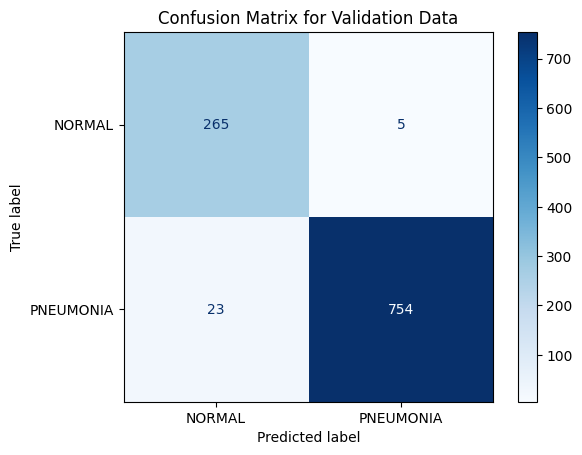

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os
import keras # Import keras to load model

# Ensure the model is loaded if not already in memory
if 'custom_effnet_optimized' not in locals():
    model_path = os.path.join(DATASET_PATH, 'best_model_f1.keras')
    custom_effnet_optimized = keras.models.load_model(model_path)
    print(f"Loaded EfficientNet model from {model_path}")

# Scale x_valid as it was scaled during training
x_valid_scaled = x_valid_hr.astype('float32') / 255.0

# Make predictions on the validation set using the best model
predictions_valid = custom_effnet_optimized.predict(x_valid_scaled)
prediction_labels_valid = np.argmax(predictions_valid, axis=1)

# Convert y_valid (one-hot encoded) back to single integer labels
y_valid_raw = np.argmax(y_valid_hr, axis=1)

# Generate classification report for validation data
print("Classification Report (Validation Data):")
print(classification_report(y_valid_raw, prediction_labels_valid, target_names=IMG_CLASSES))

# Generate confusion matrix for validation data
cm_valid = confusion_matrix(y_valid_raw, prediction_labels_valid)
disp_valid = ConfusionMatrixDisplay(confusion_matrix=cm_valid, display_labels=IMG_CLASSES)
disp_valid.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Validation Data")
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(32, 512, 512, 3))
  warnings.warn(msg)


32/33 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 512, 512, 3))
  warnings.warn(msg)


33/33 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step
Classification Report (DINOv2 Validation Data):
              precision    recall  f1-score   support

      NORMAL       0.97      0.97      0.97       270
   PNEUMONIA       0.99      0.99      0.99       777

    accuracy                           0.98      1047
   macro avg       0.98      0.98      0.98      1047
weighted avg       0.98      0.98      0.98      1047



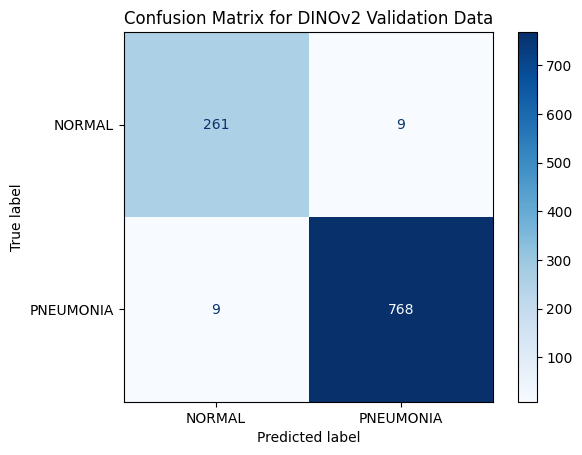

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os
import keras # Import keras to load model

# Ensure the model is loaded if not already in memory
if 'custom_dinov2_optimized' not in locals():
    model_path = os.path.join(DATASET_PATH, 'optimized_dinov2_model.keras')
    custom_dinov2_optimized = keras.models.load_model(model_path)
    print(f"Loaded DINOv2 model from {model_path}")

# Make predictions on the high-resolution validation set using the optimized DINOv2 model
# The val_datagen already handles scaling x_valid_hr
predictions_valid_dinov2 = custom_dinov2_optimized.predict(x_valid_hr.astype('float32') / 255.0)
prediction_labels_valid_dinov2 = np.argmax(predictions_valid_dinov2, axis=1)

# Convert y_valid_hr (one-hot encoded) back to single integer labels
y_valid_raw_hr_dinov2 = np.argmax(y_valid_hr, axis=1)

# Generate classification report for validation data (DINOv2)
print("Classification Report (DINOv2 Validation Data):")
print(classification_report(y_valid_raw_hr_dinov2, prediction_labels_valid_dinov2, target_names=IMG_CLASSES))

# Generate confusion matrix for validation data (DINOv2)
cm_valid_dinov2 = confusion_matrix(y_valid_raw_hr_dinov2, prediction_labels_valid_dinov2)
disp_valid_dinov2 = ConfusionMatrixDisplay(confusion_matrix=cm_valid_dinov2, display_labels=IMG_CLASSES)
disp_valid_dinov2.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for DINOv2 Validation Data")
plt.show()

### Ensemble Evaluation: Softmax Ensembling of EfficientNet and DINOv2

Generating predictions from EfficientNet model on validation data...
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step
Generating predictions from DINOv2 model on validation data...
33/33 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step

Classification Report (Ensemble Model on Validation Data):
              precision    recall  f1-score   support

      NORMAL       0.94      0.98      0.96       270
   PNEUMONIA       0.99      0.98      0.99       777

    accuracy                           0.98      1047
   macro avg       0.97      0.98      0.97      1047
weighted avg       0.98      0.98      0.98      1047



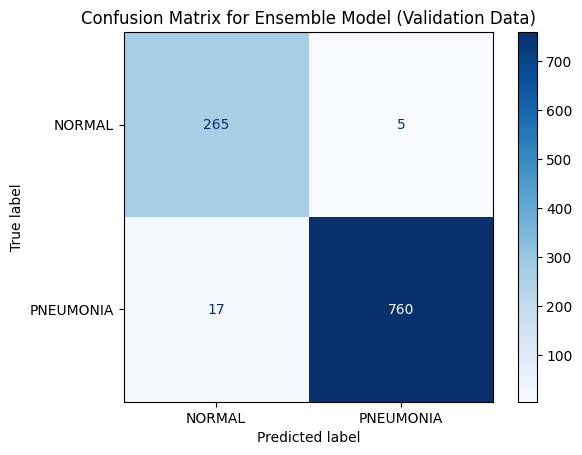

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import keras # Ensure keras is imported if models were loaded in a previous session

# Ensure models are loaded if they aren't already in memory
# (This step is redundant if the ensemble submission cell was just run, but good for robustness)
if 'custom_effnet_optimized' not in locals():
    effnet_model_path = os.path.join(DATASET_PATH, 'best_model_f1.keras')
    custom_effnet_optimized = keras.models.load_model(effnet_model_path)
    print(f"Loaded EfficientNet model from {effnet_model_path}")

if 'custom_dinov2_optimized' not in locals():
    dinov2_model_path = os.path.join(DATASET_PATH, 'optimized_dinov2_model.keras')
    custom_dinov2_optimized = keras.models.load_model(dinov2_model_path)
    print(f"Loaded DINOv2 model from {dinov2_model_path}")

# Scale x_valid_hr for prediction as it was scaled during training
x_valid_hr_scaled = x_valid_hr.astype('float32') / 255.0

# 1. Get predictions (probabilities) from each model on the VALIDATION set
print("Generating predictions from EfficientNet model on validation data...")
predictions_effnet_valid = custom_effnet_optimized.predict(x_valid_hr_scaled)

print("Generating predictions from DINOv2 model on validation data...")
predictions_dinov2_valid = custom_dinov2_optimized.predict(x_valid_hr_scaled)

# 2. Perform Softmax Ensembling
# weighted avearge based on the validatoin accuracy scores to balance the two inductive baises of each model
effnet_accuracy = 0.97 # From previous EfficientNet validation output
dino_accuracy = 0.98   # From previous DINOv2 validation output

total_accuracy = effnet_accuracy + dino_accuracy

effnet_weight = effnet_accuracy / total_accuracy
dino_weight = dino_accuracy / total_accuracy

ensemble_predictions_probs_valid = (effnet_weight * predictions_effnet_valid + dino_weight * predictions_dinov2_valid)

# Get the final predicted labels (0 or 1) based on the highest probability
ensemble_prediction_labels_valid_numerical = np.argmax(ensemble_predictions_probs_valid, axis=1)

# Convert y_valid_hr (one-hot encoded) back to single integer labels for comparison
y_valid_raw_hr_ensemble = np.argmax(y_valid_hr, axis=1)

# 3. Generate Classification Report for Ensemble
print("\nClassification Report (Ensemble Model on Validation Data):")
print(classification_report(y_valid_raw_hr_ensemble, ensemble_prediction_labels_valid_numerical, target_names=IMG_CLASSES))

# 4. Generate and Display Confusion Matrix for Ensemble
cm_ensemble_valid = confusion_matrix(y_valid_raw_hr_ensemble, ensemble_prediction_labels_valid_numerical)
disp_ensemble_valid = ConfusionMatrixDisplay(confusion_matrix=cm_ensemble_valid, display_labels=IMG_CLASSES)
disp_ensemble_valid.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Ensemble Model (Validation Data)")
plt.show()

## submission

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd # Need pandas for submission files
import keras # Import keras to load models

# Load test data assuming a flat directory structure and capturing filenames
test_images_data = []
test_filenames = []
test_dir_path = os.path.join(DATASET_PATH, 'test')

for img_name in os.listdir(test_dir_path):
    img_path = os.path.join(test_dir_path, img_name)
    img = cv2.imread(img_path)

    if img is not None:
        h, w = img.shape[:2]

        # Padding logic to make the image square, replicating load_data's behavior
        if h != w:
            diff = abs(w - h)
            pad1 = diff // 2
            pad2 = diff - pad1
            if w > h: # Wide image
                img = cv2.copyMakeBorder(img, pad1, pad2, 0, 0, cv2.BORDER_CONSTANT, value=[0, 0, 0])
            else: # Tall image
                img = cv2.copyMakeBorder(img, 0, 0, pad1, pad2, cv2.BORDER_CONSTANT, value=[0, 0, 0])

        # Now that it's a square, resize it to IMG_SIZE
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        test_images_data.append(img)
        test_filenames.append(img_name)

x_test = np.array(test_images_data)

print(f'There are {len(x_test)} Testing Images loaded, along with their filenames.')
print(f'First 5 filenames: {test_filenames[:5]}')

# Rescale the test images as done during training (datagen included rescale=1./255)
x_test_scaled = x_test.astype('float32') / 255.0

# --- Load models if not already in memory ---
if 'custom_effnet_optimized' not in locals():
    effnet_model_path = os.path.join(DATASET_PATH, 'best_model_f1.keras')
    custom_effnet_optimized = keras.models.load_model(effnet_model_path)
    print(f"Loaded EfficientNet model from {effnet_model_path}")

if 'custom_dinov2_optimized' not in locals():
    dinov2_model_path = os.path.join(DATASET_PATH, 'optimized_dinov2_model.keras')
    custom_dinov2_optimized = keras.models.load_model(dinov2_model_path)
    print(f"Loaded DINOv2 model from {dinov2_model_path}")

# --- Generate predictions for each method ---

# 1. EfficientNet only predictions
print('\nGenerating EfficientNet predictions...')
predictions_effnet = custom_effnet_optimized.predict(x_test_scaled)
prediction_labels_effnet_numerical = np.argmax(predictions_effnet, axis=1)
prediction_labels_effnet_display = [IMG_CLASSES[label] for label in prediction_labels_effnet_numerical]
print('EfficientNet predictions made successfully!')

# 2. DINOv2 only predictions
print('\nGenerating DINOv2 predictions...')
predictions_dinov2 = custom_dinov2_optimized.predict(x_test_scaled)
prediction_labels_dinov2_numerical = np.argmax(predictions_dinov2, axis=1)
prediction_labels_dinov2_display = [IMG_CLASSES[label] for label in prediction_labels_dinov2_numerical]
print('DINOv2 predictions made successfully!')

# 3. Ensemble (DINO+EffNet) predictions
print('\nGenerating Ensemble predictions...')
# Redefine weights for robustness based on the validation accuracies
effnet_accuracy = 0.97 # From previous EfficientNet validation output
dino_accuracy = 0.98   # From previous DINOv2 validation output
total_accuracy = effnet_accuracy + dino_accuracy
effnet_weight = effnet_accuracy / total_accuracy
dino_weight = dino_accuracy / total_accuracy

ensemble_predictions_probs = (effnet_weight * predictions_effnet + dino_weight * predictions_dinov2)
prediction_labels_ensemble_numerical = np.argmax(ensemble_predictions_probs, axis=1)
prediction_labels_ensemble_display = [IMG_CLASSES[label] for label in prediction_labels_ensemble_numerical]
print('Ensemble predictions made successfully!')


# --- Create and save submission files ---

# EfficientNet submission
submission_df_effnet = pd.DataFrame({
    'Id': test_filenames,
    'class': prediction_labels_effnet_display
})
submission_df_effnet.to_csv('submission_effnet.csv', index=False)
print(f"\nEfficientNet submission file 'submission_effnet.csv' created successfully.")
print(f"First 5 EfficientNet predicted labels: {prediction_labels_effnet_display[:5]}")

# DINOv2 submission
submission_df_dinov2 = pd.DataFrame({
    'Id': test_filenames,
    'class': prediction_labels_dinov2_display
})
submission_df_dinov2.to_csv('submission_dinov2.csv', index=False)
print(f"\nDINOv2 submission file 'submission_dinov2.csv' created successfully.")
print(f"First 5 DINOv2 predicted labels: {prediction_labels_dinov2_display[:5]}")

# Ensemble submission
submission_df_ensemble = pd.DataFrame({
    'Id': test_filenames,
    'class': prediction_labels_ensemble_display
})
submission_df_ensemble.to_csv('submission_ensemble.csv', index=False)
print(f"\nEnsemble submission file 'submission_ensemble.csv' created successfully.")
print(f"First 5 Ensemble predicted labels: {prediction_labels_ensemble_display[:5]}")

There are 624 Testing Images loaded, along with their filenames.
First 5 filenames: ['IM_171.jpeg', 'IM_138.jpeg', 'IM_208.jpeg', 'IM_147.jpeg', 'IM_16.jpeg']

Generating EfficientNet predictions...
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 918ms/step
EfficientNet predictions made successfully!

Generating DINOv2 predictions...
20/20 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step
DINOv2 predictions made successfully!

Generating Ensemble predictions...
Ensemble predictions made successfully!

EfficientNet submission file 'submission_effnet.csv' created successfully.
First 5 EfficientNet predicted labels: ['PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'NORMAL']

DINOv2 submission file 'submission_dinov2.csv' created successfully.
First 5 DINOv2 predicted labels: ['PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'NORMAL']

Ensemble submission file 'submission_ensemble.csv' created successfully.
First 5 Ensemble predicted labels: ['PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'NORMAL']


# Pytorch


## imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import numpy as np

# 1. Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Reproducibility Setup
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # Ensure deterministic behavior for cuDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("PyTorch setup complete.")

# set up the loas from above


Using device: cuda
PyTorch setup complete.


## data prep

In [ ]:
import numpy as np
import torch
from sklearn.model_selection import train_test_split

# Update Global Image Size to 224
IMG_SIZE = 224

print(f"Reloading dataset at {IMG_SIZE}x{IMG_SIZE}...")

# Reloading data from source folders using the previously defined load_data
train_data_raw = load_data(os.path.join(DATASET_PATH, 'train'))
valid_data_raw = load_data(os.path.join(DATASET_PATH, 'val'))

# Combine and Split to maintain consistency with the notebook's preprocessing flow
all_data_hr = train_data_raw + valid_data_raw
X_hr = np.array([item[0] for item in all_data_hr])
y_hr = np.array([item[1] for item in all_data_hr])

# Stratified split (80% train, 20% validation)
x_train, x_valid, y_train, y_valid = train_test_split(
    X_hr, y_hr, test_size=0.2, random_state=42, stratify=y_hr
)

# PyTorch CrossEntropyLoss expects raw class indices, so no one-hot encoding is needed.
# We keep y_train and y_valid as 1D arrays of integer class labels.

print(f"Success! Tensors Loaded:\nx_train shape: {x_train.shape}\nx_valid shape: {x_valid.shape}")
print(f"y_train shape: {y_train.shape} (raw indices)\ny_valid shape: {y_valid.shape} (raw indices)")

Reloading dataset at 224x224...
Success! Tensors Loaded:
x_train shape: (4185, 224, 224, 3)
x_valid shape: (1047, 224, 224, 3)
y_train shape: (4185,) (raw indices)
y_valid shape: (1047,) (raw indices)


In [ ]:
import os
import cv2
import torch
import numpy as np
import pandas as pd

# 2. Setup test data paths and preload images
test_dir_path = os.path.join(DATASET_PATH, 'test')
# Ensure we only process valid image files
test_filenames = [f for f in os.listdir(test_dir_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

print("Preloading test images...")
preloaded_test_images = []
for img_name in test_filenames:
    img_path = os.path.join(test_dir_path, img_name)
    img = cv2.imread(img_path)

    if img is not None:
        h, w = img.shape[:2]

        # Padding logic to make the image square (matches training preprocessing)
        if h != w:
            diff = abs(w - h)
            pad1 = diff // 2
            pad2 = diff - pad1
            if w > h:
                img = cv2.copyMakeBorder(img, pad1, pad2, 0, 0, cv2.BORDER_CONSTANT, value=[0, 0, 0])
            else:
                img = cv2.copyMakeBorder(img, 0, 0, pad1, pad2, cv2.BORDER_CONSTANT, value=[0, 0, 0])

        # Resize and preprocess for PyTorch (IMG_SIZE = 224)
        img = cv2.resize(img, (224, 224))
        img = img.astype(np.float32) / 255.0
        img = np.transpose(img, (2, 0, 1)) # (C, H, W) for PyTorch
        preloaded_test_images.append(img)

# Convert preloaded images to a single PyTorch tensor
test_tensor_batch = torch.tensor(np.array(preloaded_test_images)).to(device)
print(f"Preloaded {len(preloaded_test_images)} test images.")

# 3. Function to predict and save test results
def predict_and_save_results(model, test_tensors, filenames, save_path):
    print(f"Generating predictions and saving to '{save_path}'...")
    predictions_list = []

    with torch.no_grad():
        # Iterate through the preloaded tensors to avoid memory spikes from massive batches
        for i in range(test_tensors.size(0)):
            img_tensor = test_tensors[i].unsqueeze(0)  # Add batch dimension

            outputs = model(img_tensor)
            probs = torch.softmax(outputs, dim=1)
            pred = torch.argmax(probs, dim=1).item()

            predictions_list.append(IMG_CLASSES[pred])

    # Create submission file
    submission_df = pd.DataFrame({
        'Id': filenames,
        'class': predictions_list
    })

    submission_df.to_csv(save_path, index=False)
    print(f"\nSubmission file '{save_path}' created successfully.")
    print(f"First 5 predicted labels:\n{submission_df.head()}")

Preloading test images...
Preloaded 624 test images.


In [ ]:
import torch
from torch.utils.data import Dataset
import numpy as np
import cv2
import torchvision.transforms as transforms

# New class for radiological data augmentation based on user guidelines
class RadiologicalAugmentations(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.transforms = transforms.Compose([
            # Random Rotation (±5 to ±10 degrees max): Simulates patient tilt.
            transforms.RandomRotation(degrees=(-10, 10)),
            # Translation / Shifting (±5% to 10%): Simulates imperfect centration.
            # translate=(x_max_fraction, y_max_fraction)
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
            # Affine / Shearing (±2 to 5 degrees): Simulates slight body rotation.
            # shear=float or (min, max) for x-axis, (min, max) for y-axis
            transforms.RandomAffine(degrees=0, shear=(-5, 5)),
            # Contrast / Brightness Adjustments (±10%): Simulates machine variance.
            # brightness=(min_factor, max_factor), contrast=(min_factor, max_factor)
            transforms.ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1)),
        ])

    def forward(self, img_tensor):
        return self.transforms(img_tensor)

# 1. Create a Custom PyTorch Dataset
class ChestXRayDataset(Dataset):
    def __init__(self, x, y, target_size=224, transform=None):
        self.x = x
        self.y = y
        self.target_size = target_size
        self.transform = transform

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]

        # Resize to match expected model input size if needed
        if img.shape[0] != self.target_size or img.shape[1] != self.target_size:
            img = cv2.resize(img, (self.target_size, self.target_size))

        # Scale image to [0, 1] as done in Keras ImageDataGenerator
        img = img.astype(np.float32) / 255.0

        # PyTorch expects channel-first format (C, H, W)
        img = np.transpose(img, (2, 0, 1))
        img_tensor = torch.tensor(img)

        # Apply data augmentations if any
        if self.transform:
            img_tensor = self.transform(img_tensor)

        label = self.y[idx]
        return img_tensor, torch.tensor(label, dtype=torch.long)

# Since we updated the data loading step, y_train and y_valid are already 1D arrays.
# We don't need np.argmax anymore.
y_train_raw = y_train
y_valid_raw = y_valid


In [ ]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

# Define data augmentation suitable for X-Rays (matching optimized Keras params)
train_transforms = transforms.Compose([
    transforms.RandomRotation(degrees=5),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), shear=5),
    transforms.RandomHorizontalFlip(p=0.5)
])

# 2. Setup DataLoaders
BATCH_SIZE = 32  # Same as optimized DINOv2

# Apply transforms only to the training dataset
train_dataset = ChestXRayDataset(x_train, y_train_raw, target_size=224, transform=train_transforms)
valid_dataset = ChestXRayDataset(x_valid, y_valid_raw, target_size=224)

# Added num_workers, pin_memory, and drop_last to speed up data loading and avoid BatchNorm crashes!
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


## simple baseline

In [ ]:
!pip install -q transformers

import torch
import torch.nn as nn
from transformers import AutoModel

class RadDinoClassifierBaseline(nn.Module):
    def __init__(self, num_classes=2, freeze_backbone=True):
        super(RadDinoClassifierBaseline, self).__init__()

        # 1. Load the pre-trained RAD-DINO backbone from Hugging Face
        self.backbone = AutoModel.from_pretrained("microsoft/rad-dino")

        # Freeze backbone weights if transfer learning is desired
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # 2. Build a robust classification head
        self.head = nn.Sequential(
            nn.Linear(768,64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, pixel_values):
        # Forward pass through the backbone
        outputs = self.backbone(pixel_values=pixel_values)

        # Extract the CLS token (index 0) from the last hidden state
        cls_token = outputs.last_hidden_state[:, 0, :]

        # Pass the CLS token through the classification head
        logits = self.head(cls_token)
        return logits

# Instantiate the SOTA PyTorch model
baseline_pytorch_model = RadDinoClassifierBaseline(num_classes=2, freeze_backbone=True)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline_pytorch_model = baseline_pytorch_model.to(device)

print(baseline_pytorch_model)
print(f"\nModel successfully built and moved to {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/879 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

RadDinoClassifierBaseline(
  (backbone): Dinov2Model(
    (embeddings): Dinov2Embeddings(
      (patch_embeddings): Dinov2PatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): Dinov2Encoder(
      (layer): ModuleList(
        (0-11): 12 x Dinov2Layer(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attention): Dinov2Attention(
            (attention): Dinov2SelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): Dinov2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (layer_scale1): Dinov2Layer

In [ ]:
# 3. Setup Optimizer, Loss Function, and Params
import time

EPOCHS = 50
LR = 5e-5

# Class weights matching Keras dictionary {0: 0.4, 1: 0.6}
class_weights = torch.tensor([0.4, 0.6], dtype=torch.float32).to(device)

# Loss with label smoothing 0.15
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.15)
optimizer = optim.AdamW(baseline_pytorch_model.parameters(), lr=LR)

# 4. Training Loop
print(f"Starting training on {device}...")
best_val_f1 = 0.0

for epoch in range(EPOCHS):
    start_time = time.time()

    # --- Training Phase ---
    baseline_pytorch_model.train()
    train_loss = 0.0

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = baseline_pytorch_model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)

    train_loss = train_loss / len(train_loader.dataset)

    # --- Validation Phase ---
    baseline_pytorch_model.eval()
    val_loss = 0.0
    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for inputs, targets in valid_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = baseline_pytorch_model(inputs)
            loss = criterion(outputs, targets)

            val_loss += loss.item() * inputs.size(0)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs[:, 1].cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    val_loss = val_loss / len(valid_loader.dataset)

    # Calculate Metrics
    val_acc = accuracy_score(all_targets, all_preds)
    val_f1 = f1_score(all_targets, all_preds, average='macro')
    val_auc = roc_auc_score(all_targets, all_probs)

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{EPOCHS} [{epoch_time:.0f}s] - "
          f"Train Loss: {train_loss:.4f} - "
          f"Val Loss: {val_loss:.4f} - "
          f"Val Acc: {val_acc:.4f} - "
          f"Val F1: {val_f1:.4f} - "
          f"Val AUC: {val_auc:.4f}")

    # Simple model checkpointing based on best macro F1
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(baseline_pytorch_model.state_dict(), "best_raddino_model.pth")
        print(f"  >> Saved new best model with Val F1: {best_val_f1:.4f}")

Starting training on cuda...


KeyboardInterrupt: 

In [ ]:
# 1. Load the best model weights from training
baseline_pytorch_model.load_state_dict(torch.load("best_raddino_model.pth"))
baseline_pytorch_model.eval()

# Call the function to predict and save
predict_and_save_results(baseline_pytorch_model, test_tensor_batch, test_filenames, 'submission_raddino_pytorch.csv')


## embed + xgboost

In [ ]:
!pip install -q transformers xgboost timm huggingface_hub

import torch
import numpy as np
from transformers import AutoModel
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import time
import timm
from huggingface_hub import hf_hub_download

# 1. Load the pre-trained RAD-DINO backbone from Hugging Face
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("Loading RAD-DINO backbone...")
rad_dino_model = AutoModel.from_pretrained("microsoft/rad-dino")
rad_dino_model = rad_dino_model.to(device)
rad_dino_model.eval()

# 2. Function to extract features (only RAD-DINO)
def extract_features(dataloader, rad_model, device):
    features = []
    labels = []

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)

            # Forward pass through the RAD-DINO backbone
            rad_outputs = rad_model(pixel_values=inputs)
            # Extract the CLS token (index 0) from the last hidden state
            rad_cls_token = rad_outputs.last_hidden_state[:, 0, :]

            features.extend(rad_cls_token.cpu().numpy())
            labels.extend(targets.numpy())

    return np.array(features), np.array(labels)

# 3. Extract features for training and validation sets
print("Extracting features from training set...")
start_time = time.time()
x_train_features, y_train_labels = extract_features(train_loader, rad_dino_model, device)
print(f"Training features extracted in {time.time() - start_time:.2f} seconds. Shape: {x_train_features.shape}")

print("Extracting features from validation set...")
start_time = time.time()
x_valid_features, y_valid_labels = extract_features(valid_loader, rad_dino_model, device)
print(f"Validation features extracted in {time.time() - start_time:.2f} seconds. Shape: {x_valid_features.shape}")

# 4. Train XGBoost classifier
print("Training XGBoost classifier...")
# Calculate scale_pos_weight based on class distribution for handling imbalance
# Normal (0): 0.4 weight, Pneumonia (1): 0.6 weight -> roughly reflects imbalance, but let's let XGBoost handle it or calculate exact
num_normal = np.sum(y_train_labels == 0)
num_pneumonia = np.sum(y_train_labels == 1)
scale_pos_weight = num_normal / num_pneumonia if num_pneumonia > 0 else 1.0

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    early_stopping_rounds=50,
    random_state=42
)

xgb_model.fit(
    x_train_features,
    y_train_labels,
    eval_set=[(x_train_features, y_train_labels), (x_valid_features, y_valid_labels)],
    verbose=50
)

# 5. Evaluate
print("\nEvaluating XGBoost model...")
preds = xgb_model.predict(x_valid_features)
probs = xgb_model.predict_proba(x_valid_features)[:, 1]

val_acc = accuracy_score(y_valid_labels, preds)
val_f1 = f1_score(y_valid_labels, preds, average='macro')
val_auc = roc_auc_score(y_valid_labels, probs)

print(f"XGBoost Validation Accuracy: {val_acc:.4f}")
print(f"XGBoost Validation F1-Score (macro): {val_f1:.4f}")
print(f"XGBoost Validation AUC: {val_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_valid_labels, preds, target_names=IMG_CLASSES))


Using device: cuda
Loading RAD-DINO backbone...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Extracting features from training set...


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import torch
import numpy as np

print("Extracting RAD-DINO features for the test set...")
test_features = []
batch_size = 16

with torch.no_grad():
    for i in range(0, len(test_tensor_batch), batch_size):
        batch = test_tensor_batch[i:i+batch_size]

        # RAD-DINO features
        rad_outputs = rad_dino_model(pixel_values=batch)
        rad_cls_token = rad_outputs.last_hidden_state[:, 0, :]

        test_features.extend(rad_cls_token.cpu().numpy())

test_features = np.array(test_features)
print(f"Test features extracted. Shape: {test_features.shape}")

print("Generating XGBoost predictions...")
xgb_test_preds = xgb_model.predict(test_features)
xgb_test_pred_labels = [IMG_CLASSES[p] for p in xgb_test_preds]

# Create submission file
submission_df_xgb = pd.DataFrame({
    'Id': test_filenames,
    'class': xgb_test_pred_labels
})

xgb_save_path = 'submission_raddino_xgboost.csv'
submission_df_xgb.to_csv(xgb_save_path, index=False)
print(f"\nSubmission file '{xgb_save_path}' created successfully.")
print(f"First 5 XGBoost predicted labels:\n{submission_df_xgb.head()}")


Extracting RAD-DINO features for the test set...
Test features extracted. Shape: (624, 768)
Generating XGBoost predictions...

Submission file 'submission_raddino_xgboost.csv' created successfully.
First 5 XGBoost predicted labels:
            Id      class
0  IM_171.jpeg  PNEUMONIA
1  IM_138.jpeg  PNEUMONIA
2  IM_208.jpeg  PNEUMONIA
3  IM_147.jpeg  PNEUMONIA
4   IM_16.jpeg     NORMAL


## multi-modal classification

In [ ]:
!pip install -q open_clip_torch
import torch
import torch.nn as nn
from transformers import AutoModel # Keep AutoModel for RadDino
import open_clip # New import

class RadDinoBiomedClipClassifier(nn.Module):
    def __init__(self, num_classes=2, mid_layer_dim = 64, freeze_backbones=True, use_cls_token=True):
        super(RadDinoBiomedClipClassifier, self).__init__()
        self.use_cls_token = use_cls_token
        self.mid_layer_dim = mid_layer_dim
        # 1. Load RAD-DINO
        print("Loading RAD-DINO...")
        self.raddino = AutoModel.from_pretrained("microsoft/rad-dino")

        # 2. Load BiomedCLIP Vision Model with open_clip
        print("Loading BiomedCLIP Vision Model with open_clip...")
        biomed_clip_model_id = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
        # open_clip.create_model_from_pretrained returns model and preprocess_transform
        full_biomed_clip_model, _ = open_clip.create_model_from_pretrained(biomed_clip_model_id)
        self.biomed_clip_vision = full_biomed_clip_model.visual # Access the visual encoder part
        # Removed biomed_clip_processor as it's not used directly by the vision model's forward pass

        if freeze_backbones:
            for param in self.raddino.parameters():
                param.requires_grad = False
            for param in self.biomed_clip_vision.parameters(): # Freeze BiomedCLIP
                param.requires_grad = False

        # Move backbones to device immediately after loading and freezing
        self.raddino = self.raddino.to(device)
        self.biomed_clip_vision = self.biomed_clip_vision.to(device)
        self.raddino.eval() # Set to eval mode
        self.biomed_clip_vision.eval() # Set to eval mode

        # 3. Lean Regularized MLP with GELU
        # RAD-DINO CLS token is 768 dims
        # BiomedCLIP visual features from open_clip are typically 512 for ViT-B/16
        raddino_feature_dim = 768
        biomed_feature_dim = 512

        self.norm_raddino = nn.LayerNorm(raddino_feature_dim)
        self.norm_biomed = nn.LayerNorm(biomed_feature_dim)

        if not self.use_cls_token:
            # If not using CLS token, process patch tokens with 1D CNN
            # Input to Conv1d: (batch, channels, length). Patch tokens are (batch, num_patches, hidden_dim).
            # So, we permute to (batch, hidden_dim, num_patches).
            self.raddino_cnn_processor = nn.Sequential(
                nn.Conv1d(in_channels=raddino_feature_dim, out_channels=512, kernel_size=3, padding='same'),
                nn.GELU(),
                nn.AdaptiveAvgPool1d(1) # Aggregates features along the sequence dimension, output (batch, raddino_feature_dim, 1)
            )
            raddino_processed_dim = raddino_feature_dim # Output dimension after CNN and pooling
        else:
            raddino_processed_dim = raddino_feature_dim # CLS token dimension

        in_features = raddino_processed_dim + biomed_feature_dim

        # Split MLP into projection head and output layer
        self.projection_head = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Linear(in_features, mid_layer_dim),
            nn.GELU(),
            nn.Dropout(0.5), # Regularization
        )
        self.output_layer = nn.Linear(mid_layer_dim, num_classes)

    def forward(self, pixel_values):
        # RAD-DINO features
        raddino_out = self.raddino(pixel_values=pixel_values)

        if self.use_cls_token:
            raddino_features = raddino_out.last_hidden_state[:, 0, :]
            raddino_features = self.norm_raddino(raddino_features)
        else:
            # Extract patch tokens (exclude CLS token at index 0)
            patch_tokens = raddino_out.last_hidden_state[:, 1:, :] # (batch, num_patches, hidden_dim)
            # Permute for Conv1d: (batch, hidden_dim, num_patches)
            patch_tokens_permuted = patch_tokens.permute(0, 2, 1)
            # Pass through 1D CNN and squeeze the last dimension (which is 1 after AdaptiveAvgPool1d)
            cnn_output = self.raddino_cnn_processor(patch_tokens_permuted).squeeze(-1) # (batch, hidden_dim)
            raddino_features = self.norm_raddino(cnn_output) # Normalize the aggregated features

        # BiomedCLIP features from open_clip's visual encoder
        # open_clip's visual encoder (self.biomed_clip_vision) typically takes the image tensor directly
        # and returns the features.
        biomed_clip_features = self.biomed_clip_vision(pixel_values)
        biomed_clip_features = self.norm_biomed(biomed_clip_features)

        # Concatenate features
        combined_features = torch.cat((raddino_features, biomed_clip_features), dim=1);

        # Pass through projection head to get hidden features
        hidden_features = self.projection_head(combined_features)

        # Pass hidden features through output layer
        logits = self.output_layer(hidden_features)

        # Return logits and hidden features
        return logits, hidden_features

In [ ]:
import time # Added to resolve NameError
import torch.nn as nn # Ensure nn is imported if not already in context
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score # Ensure these are imported for metrics
import torch
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler # Import for Cosine Annealing

# User-provided DecorrelationLoss class
class DecorrelationLoss(nn.Module):
    def __init__(self, alpha=1e-3):
        super(DecorrelationLoss, self).__init__()
        self.alpha = alpha # Regularization strength

    def forward(self, features):
        # Features shape: (Batch_Size, Feature_Dim)
        batch_size, feature_dim = features.shape

        # Handle batch_size = 1 to prevent division by zero in covariance calculation
        if batch_size <= 1:
            return torch.tensor(0.0, device=features.device, dtype=features.dtype)

        # 1. Center the features by subtracting the mean of the batch
        mean = features.mean(dim=0)
        centered_features = features - mean

        # 2. Calculate the Covariance Matrix: (Feature_Dim, Feature_Dim)
        cov_matrix = (centered_features.T @ centered_features) / (batch_size - 1)

        # 3. Isolate the off-diagonal elements (the correlations between different features)
        diag = torch.diag(cov_matrix)
        diag_matrix = torch.diag_embed(diag)
        off_diag_matrix = cov_matrix - diag_matrix

        # 4. Calculate the Frobenius norm (sum of squares) of the off-diagonal elements
        decorrelation_penalty = torch.sum(off_diag_matrix ** 2)

        return self.alpha * decorrelation_penalty

# Instantiate the ensemble model before the training loop
# Assuming RadDinoBiomedClipClassifier is defined in a preceding cell (ad1TIlsWFfXL)
# and device is set up.
ensemble_model = RadDinoBiomedClipClassifier(num_classes=2, freeze_backbones=True)
ensemble_model = ensemble_model.to(device) # Move model to the correct device

# Setup Optimizer with L2 Regularization (weight_decay), Loss Function, and Params
EPOCHS = 50
LR = 5e-5
L2_REG = 1e-4 # Explicit L2 Regularization parameter
DECORR_REG = 5e-5

# Early Stopping parameters
PATIENCE = 7
min_delta = 0.001

# Class weights set to None (default) as requested
class_weights = None

# Loss with label smoothing 0.15
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# Instantiate DecorrelationLoss
decorrelation_criterion = DecorrelationLoss(DECORR_REG) # Adjust alpha as needed

# AdamW applies L2 regularization via the weight_decay argument
optimizer = optim.AdamW(ensemble_model.parameters(), lr=LR, weight_decay=L2_REG)

# Cosine Annealing Learning Rate Scheduler
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS) # T_max is the number of epochs

# 4. Training Loop for Ensemble Model
print(f"Starting training on {device}...")
best_val_f1_ensemble = 0.0
patience_counter = 0

for epoch in range(EPOCHS):
    start_time = time.time()

    # --- Training Phase ---
    ensemble_model.train()
    train_loss = 0.0

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        model_output = ensemble_model(inputs)
        if isinstance(model_output, tuple):
            outputs, features = model_output
        else:
            outputs = model_output
            features = None

        loss_cls = criterion(outputs, targets)

        loss_decorrelation = 0.0
        if features is not None:
            loss_decorrelation = decorrelation_criterion(features)
        else:
            print("Warning: DecorrelationLoss not applied. `ensemble_model` in `ad1TIlsWFfXL` needs to return features.")

        loss = loss_cls + loss_decorrelation # Combine classification and decorrelation losses

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)

    train_loss = train_loss / len(train_loader.dataset)

    # --- Validation Phase ---
    ensemble_model.eval()
    val_loss = 0.0
    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for inputs, targets in valid_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = ensemble_model(inputs)
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            loss = criterion(outputs, targets)

            val_loss += loss.item() * inputs.size(0)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs[:, 1].cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    val_loss = val_loss / len(valid_loader.dataset)

    # Calculate Metrics
    val_acc = accuracy_score(all_targets, all_preds)
    val_f1 = f1_score(all_targets, all_preds, average='macro')
    val_auc = roc_auc_score(all_targets, all_probs)

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{EPOCHS} [{epoch_time:.0f}s] - "
          f"Train Loss: {train_loss:.4f} - "
          f"Val Loss: {val_loss:.4f} - "
          f"Val Acc: {val_acc:.4f} - "
          f"Val F1: {val_f1:.4f} - "
          f"Val AUC: {val_auc:.4f}")

    # Checkpointing and Early Stopping
    if val_f1 > best_val_f1_ensemble + min_delta:
        best_val_f1_ensemble = val_f1
        torch.save(ensemble_model.state_dict(), "best_ensemble_raddino_biomedclip.pth")
        print(f"  >> Saved new best model with Val F1: {best_val_f1_ensemble:.4f}")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  >> EarlyStopping patience: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print(f"  >> Early stopping triggered at epoch {epoch+1}")
            break

    # Step the learning rate scheduler
    scheduler.step()

Loading RAD-DINO...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loading BiomedCLIP Vision Model with open_clip...
Starting training on cuda...
Epoch 1/50 [147s] - Train Loss: 0.4500 - Val Loss: 0.3763 - Val Acc: 0.9016 - Val F1: 0.8836 - Val AUC: 0.9918
  >> Saved new best model with Val F1: 0.8836
Epoch 2/50 [145s] - Train Loss: 0.3336 - Val Loss: 0.3211 - Val Acc: 0.9303 - Val F1: 0.9152 - Val AUC: 0.9944
  >> Saved new best model with Val F1: 0.9152
Epoch 3/50 [145s] - Train Loss: 0.2987 - Val Loss: 0.2734 - Val Acc: 0.9599 - Val F1: 0.9493 - Val AUC: 0.9959
  >> Saved new best model with Val F1: 0.9493
Epoch 4/50 [145s] - Train Loss: 0.2879 - Val Loss: 0.2642 - Val Acc: 0.9647 - Val F1: 0.9550 - Val AUC: 0.9966
  >> Saved new best model with Val F1: 0.9550
Epoch 5/50 [145s] - Train Loss: 0.2822 - Val Loss: 0.2582 - Val Acc: 0.9685 - Val F1: 0.9596 - Val AUC: 0.9970
  >> Saved new best model with Val F1: 0.9596
Epoch 6/50 [145s] - Train Loss: 0.2784 - Val Loss: 0.2545 - Val Acc: 0.9704 - Val F1: 0.9620 - Val AUC: 0.9971
  >> Saved new best model

In [ ]:
import torch
import pandas as pd # Ensure pandas is imported
import numpy as np # Ensure numpy is imported

# Redefine the predict_and_save_results function to handle tuple output from the model
def predict_and_save_results(model, test_tensors, filenames, save_path):
    print(f"Generating predictions and saving to '{save_path}'...")
    predictions_list = []

    # Assuming IMG_CLASSES is available in the global scope from previous cells
    global IMG_CLASSES

    with torch.no_grad():
        for i in range(test_tensors.size(0)):
            img_tensor = test_tensors[i].unsqueeze(0)  # Add batch dimension

            model_output = model(img_tensor)
            # Check if the output is a tuple (logits, features) or just logits
            if isinstance(model_output, tuple):
                outputs = model_output[0] # Take the logits
            else:
                outputs = model_output # Assume it's already the logits

            probs = torch.softmax(outputs, dim=1)
            pred = torch.argmax(probs, dim=1).item()

            predictions_list.append(IMG_CLASSES[pred])

    # Create submission file
    submission_df = pd.DataFrame({
        'Id': filenames,
        'class': predictions_list
    })

    submission_df.to_csv(save_path, index=False)
    print(f"\nSubmission file '{save_path}' created successfully.")
    print(f"First 5 predicted labels:\n{submission_df.head()}")

# Load the best model weights
ensemble_model.load_state_dict(torch.load("best_ensemble_raddino_biomedclip.pth"))
ensemble_model.eval()

# Call the function to predict and save
predict_and_save_results(ensemble_model, test_tensor_batch, test_filenames, 'submission_ensemble_raddino_biomedclip.csv')

Generating predictions and saving to 'submission_ensemble_raddino_biomedclip.csv'...

Submission file 'submission_ensemble_raddino_biomedclip.csv' created successfully.
First 5 predicted labels:
            Id      class
0  IM_171.jpeg  PNEUMONIA
1  IM_138.jpeg  PNEUMONIA
2  IM_208.jpeg  PNEUMONIA
3  IM_147.jpeg  PNEUMONIA
4   IM_16.jpeg     NORMAL
